## Task 1: Text Loading, Cleaning, Tokenisation & Padding


In [1]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

### Load and inspect

In [7]:
df = pd.read_csv("IMDB Dataset.csv")

print("Dataset Shape:", df.shape)

print("\nFirst 5 Rows:")
print(df.head())



Dataset Shape: (50000, 2)

First 5 Rows:
                                              review sentiment
0  One of the other reviewers has mentioned that ...  positive
1  A wonderful little production. <br /><br />The...  positive
2  I thought this was a wonderful way to spend ti...  positive
3  Basically there's a family where a little boy ...  negative
4  Petter Mattei's "Love in the Time of Money" is...  positive


In [8]:
print("\nSentiment Count:")
print(df["sentiment"].value_counts())

print("\nMissing Values:")
print(df.isnull().sum())


Sentiment Count:
sentiment
positive    25000
negative    25000
Name: count, dtype: int64

Missing Values:
review       0
sentiment    0
dtype: int64


In [10]:
print("Review 1:")
print(df["review"].iloc[0])

print("\nReview 2:")
print(df["review"].iloc[1])

Review 1:
One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is called OZ as that is the nickname given to the Oswald Maximum Security State Penitentary. It focuses mainly on Emerald City, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. Em City is home to many..Aryans, Muslims, gangstas, Latinos, Christians, Italians, Irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away.<br /><br />I would say the main appeal of the show is due 

### Remove duplicates

In [12]:
print("Rows before removing duplicates:", len(df))

Rows before removing duplicates: 50000


In [17]:
duplicate_count = df.duplicated().sum()
print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


In [14]:
df.drop_duplicates(inplace=True)

In [20]:
print("Rows after removing duplicates:", len(df))

Rows after removing duplicates: 49582


### Clean the text

In [ ]:
def clean_text(s):
    s = s.lower()
    s = re.sub(r'<.*?>', ' ', s)
    s = re.sub(r"[^a-zA-Z']", ' ', s)
    s = re.sub(r'\s+', ' ', s)
    return s.strip()

df['cleaned_review'] = df['review'].apply(clean_text)

print("Before Cleaning:")
print(df['review'].iloc[0])

print("\nAfter Cleaning:")
print(df['cleaned_review'].iloc[0])

Before Cleaning:
One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is called OZ as that is the nickname given to the Oswald Maximum Security State Penitentary. It focuses mainly on Emerald City, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. Em City is home to many..Aryans, Muslims, gangstas, Latinos, Christians, Italians, Irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away.<br /><br />I would say the main appeal of the show 

#### Clean the Text :

The review text is cleaned using the following steps:

1. Convert all text to lowercase.
2. Remove HTML tags using `re.sub(r'<.*?>', ' ', s)`.
3. Remove characters other than letters and apostrophes.
4. Collapse repeated spaces into a single space.

**Why are apostrophes kept?**  
Apostrophes are kept because words such as `don't` and `can't` contain apostrophes, and they are important parts of the original words.

**Why are stop-words NOT removed?**  
Stop-words are not removed because words such as `not` and `no` can change the sentiment of a review. Also, word order is important for sequence models.

**Interpretation:**  
After cleaning, the reviews become more consistent and easier for the model to process while keeping important sentiment information.

### Review length analysis

In [22]:
df['review_length'] = df['cleaned_review'].apply(lambda x: len(x.split()))

print(df['review_length'].head())

0    307
1    158
2    164
3    130
4    225
Name: review_length, dtype: int64


In [23]:
mean_length = df['review_length'].mean()
median_length = df['review_length'].median()
p95_length = df['review_length'].quantile(0.95)

print("Mean:", mean_length)
print("Median:", median_length)
print("95th Percentile:", p95_length)

Mean: 229.96151829292887
Median: 172.0
95th Percentile: 587.0


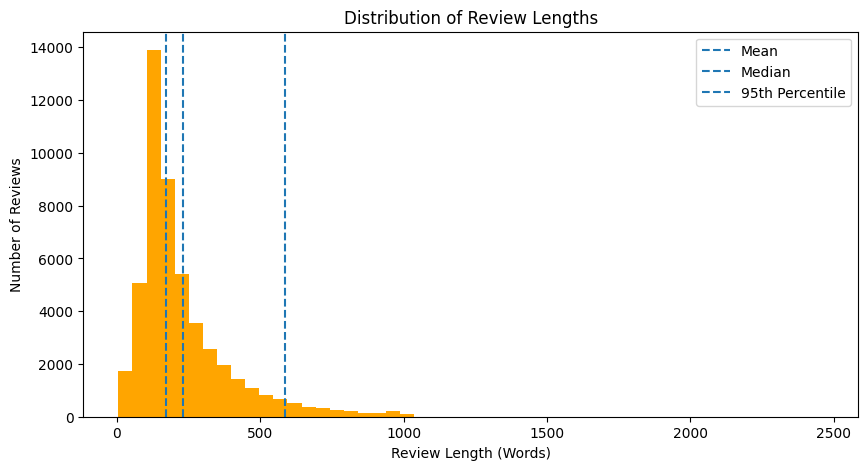

In [26]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.hist(df['review_length'], bins=50, color='orange')

plt.axvline(mean_length, linestyle='--', label='Mean')
plt.axvline(median_length, linestyle='--', label='Median')
plt.axvline(p95_length, linestyle='--', label='95th Percentile')

plt.xlabel('Review Length (Words)')
plt.ylabel('Number of Reviews')
plt.title('Distribution of Review Lengths')
plt.legend()
plt.show()

<Figure size 800x500 with 0 Axes>

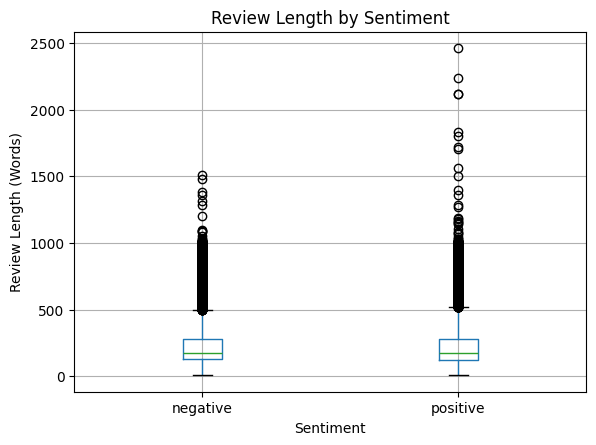

In [27]:
plt.figure(figsize=(8, 5))

df.boxplot(column='review_length', by='sentiment')

plt.xlabel('Sentiment')
plt.ylabel('Review Length (Words)')
plt.title('Review Length by Sentiment')
plt.suptitle('')

plt.show()

In [28]:
MAXLEN = round(p95_length / 10) * 10

print("Selected MAXLEN:", MAXLEN)

Selected MAXLEN: 590


#### Review Length Analysis – Interpretation

The review lengths show how many words are present in each review. 
The histogram helps us understand the distribution using the mean, median, and 95th percentile.

The boxplot compares review lengths between positive and negative sentiments and shows the presence of outliers.

For padding, `MAXLEN` is selected around the 90th–95th percentile of review length and rounded to a convenient value. This keeps most of the important review text while avoiding excessive padding.

### Tokenise

In [30]:
from sklearn.model_selection import train_test_split

# Input and target
X = df['cleaned_review']
y = df['sentiment'].map({'positive': 1, 'negative': 0})

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data:", len(X_train))
print("Testing data:", len(X_test))

Training data: 39665
Testing data: 9917


In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer

tokenizer = Tokenizer(
    num_words=10000,
    oov_token='<OOV>'
)

tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

print("Top 10 most frequent words:")

for word, index in list(tokenizer.word_index.items())[:10]:
    print(word, ":", index)

print("\nInteger sequence of one review:")
print(X_train_seq[0])

Top 10 most frequent words:
<OOV> : 1
the : 2
and : 3
a : 4
of : 5
to : 6
is : 7
in : 8
it : 9
i : 10

Integer sequence of one review:
[10, 234, 27, 5, 1, 4935, 3, 10, 81, 158, 8, 32, 1, 454, 2767, 7929, 121, 2, 151, 10, 25, 105, 83, 705, 35, 1, 3781, 6, 547, 1, 25, 6453, 1909, 1, 20, 547, 1417, 1, 3, 25, 105, 438, 4986, 428, 605, 1742, 35, 1, 8533, 31, 1, 547, 10, 25, 81, 548, 438, 1, 4935, 109, 561, 12, 33, 79, 705, 43, 33, 5805, 547, 3, 100, 151, 8, 2, 1843, 10, 25, 111, 159, 105, 9, 576, 1204, 2, 899, 7, 9, 62, 1, 6, 5805, 547, 1, 38, 7, 2, 1918, 30, 1028, 1, 35, 2, 927, 20, 11, 1755, 2, 1755, 15, 1, 4935, 7, 4, 1527, 27, 22, 206, 1, 35, 547, 7, 21, 32, 5465, 2566, 1390, 22, 15, 11, 16, 3, 3499, 784, 20, 9]


#### Tokenisation

The text data is converted into integer sequences using the Keras `Tokenizer`.

- `num_words=10000` keeps the 10,000 most frequent words in the vocabulary.
- `oov_token='<OOV>'` represents words that are not present in the selected vocabulary.
- The tokenizer is fitted only on the training texts to avoid data leakage.
- The training and testing reviews are converted into integer sequences.

**Why `num_words=10000`?**  
Keeping the 10,000 most frequent words reduces unnecessary parameters and noise caused by very rare words.

**What does the OOV token do?**  
The `<OOV>` token represents unknown or out-of-vocabulary words that are not included in the selected 10,000-word vocabulary.

**Interpretation:**  
Tokenisation converts each review from text into a sequence of integer values. These integer sequences can then be used as input for the RNN, LSTM, and GRU models.

### Pad / truncate and split

In [32]:
X = df['cleaned_review']
y = df['sentiment'].map({'positive': 1, 'negative': 0})

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

X_train_pad = pad_sequences(
    X_train_seq,
    maxlen=MAXLEN,
    padding='pre',
    truncating='pre'
)

X_test_pad = pad_sequences(
    X_test_seq,
    maxlen=MAXLEN,
    padding='pre',
    truncating='pre'
)

print("X_train shape:", X_train_pad.shape)
print("X_test shape:", X_test_pad.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (39665, 590)
X_test shape: (9917, 590)
y_train shape: (39665,)
y_test shape: (9917,)


#### Pad / Truncate and Split

The cleaned reviews are first divided into training and testing sets using an 80/20 split with `random_state=42` and `stratify=y`.

The tokenizer converts the reviews into integer sequences, and `pad_sequences()` makes all sequences the same length using `MAXLEN`.

`padding='pre'` adds zeros at the beginning of shorter sequences, while `truncating='pre'` removes words from the beginning of longer sequences.

**Why is pre-padding preferred for RNNs that read the last time step?**  
Pre-padding keeps the actual words at the end of the sequence. Therefore, when the RNN uses the final hidden state, it is based on real words rather than a long sequence of zeros.

**Interpretation:**  
After padding, every review has the same length, so the data can be directly provided to the RNN, LSTM, and GRU models.

### Sequence vs bag-of-words — Markdown

#### Sequence vs Bag-of-Words

This data is **sequential** because the order of words affects the meaning of a sentence.

For example:

- **"The movie was not good."**
- **"The movie was good, not bad."**

These sentences contain nearly the same words, but their meanings and sentiments are different.

A Bag-of-Words model mainly considers which words are present and ignores their order. Therefore, it may not correctly distinguish between these sentences.

Sequence models such as **RNN, LSTM, and GRU** consider the order of words, which helps them understand the context and sentiment of the review.

**Interpretation:**  
Word order is important in sentiment analysis because changing the position of words can change the meaning. This motivates the use of sequential models in Task 2.

## Task 2: RNN Intuition, RNN vs ANN & Forward Propagation


### Baseline ANN on text

In [34]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Flatten, Dense

ann_model = Sequential([
    Embedding(input_dim=10000, output_dim=32, input_length=MAXLEN),
    Flatten(),
    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid')
])

ann_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

ann_model.summary()

history = ann_model.fit(
    X_train_pad,
    y_train,
    epochs=5,
    validation_split=0.1,
    batch_size=64
)

test_loss, test_accuracy = ann_model.evaluate(
    X_test_pad,
    y_test
)

print("Test Accuracy:", test_accuracy)
print("Total Parameters:", ann_model.count_params())

C:\Users\JANKI DHOLARIYA\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\core\embedding.py:123: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
558/558 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.8142 - loss: 0.3872 - val_accuracy: 0.8835 - val_loss: 0.2805
Epoch 2/5
558/558 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.9426 - loss: 0.1560 - val_accuracy: 0.8732 - val_loss: 0.3242
Epoch 3/5
558/558 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.9902 - loss: 0.0351 - val_accuracy: 0.8697 - val_loss: 0.4352
Epoch 4/5
558/558 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.9996 - loss: 0.0047 - val_accuracy: 0.8775 - val_loss: 0.5031
Epoch 5/5
558/558 ━━━━━━━━━━━━━━━━━━━━ 10s 18ms/step - accuracy: 0.9999 - loss: 9.6596e-04 - val_accuracy: 0.8762 - val_loss: 0.5531
310/310 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.8799 - loss: 0.5499
Test Accuracy: 0.8799031972885132
Total Parameters: 1528449


#### Baseline ANN on Text

The baseline ANN uses the following architecture:

**Embedding → Flatten → Dense(64, ReLU) → Dense(1, Sigmoid)**

The model is compiled using the Adam optimizer and binary crossentropy loss. It is trained for 5 epochs with 10% of the training data used for validation.

**Why is this ANN order-blind?**  
The `Flatten` layer converts the embedding sequence into one long vector. Each position in the sequence is treated as an independent input slot, so the ANN does not properly learn the relationship between word positions.

The model also cannot share what it learns about a word across different positions. Therefore, the same word appearing at different positions is treated as a different set of inputs.

**Parameter count:**  
The parameter count of the ANN increases as `MAXLEN` increases because the `Flatten` layer creates more inputs for the Dense layer.

**Interpretation:**  
This ANN provides a baseline for comparison. It does not effectively use word order, which motivates the use of sequential models such as RNN, LSTM, and GRU in the next tasks.

### RNN intuition — Markdown

#### RNN Intuition

An **RNN (Recurrent Neural Network)** reads a sequence one word at a time. At each time step, it maintains a **hidden state `h(t)`**, which summarizes the information read from the sequence so far.

The same weights are reused at every time step. This is called **weight sharing across time**. Therefore, the RNN can handle sequences of different lengths without increasing the number of model parameters.

#### Hidden State Equation

\[
h(t) = \tanh(W_{xh} \cdot x(t) + W_{hh} \cdot h(t-1) + b)
\]

Where:

- **`h(t)`** → current hidden state containing information from the current and previous words.
- **`x(t)`** → input at the current time step (current word).
- **`h(t-1)`** → previous hidden state containing information from earlier words.
- **`W_xh`** → weights connecting the current input to the hidden state.
- **`W_hh`** → weights connecting the previous hidden state to the current hidden state.
- **`b`** → bias term.
- **`tanh`** → activation function that produces the new hidden state.

#### Output Equation

\[
y(t) = f(W_{hy} \cdot h(t) + b_y)
\]

Where:

- **`y(t)`** → output at the current time step.
- **`W_hy`** → weights connecting the hidden state to the output.
- **`h(t)`** → current hidden state.
- **`b_y`** → output bias.
- **`f`** → output activation function.


### Manual forward propagation in NumPy

In [36]:
import matplotlib.pyplot as plt

np.random.seed(42)

input_size = 2
hidden_size = 3

Wxh = np.random.randn(hidden_size, input_size) * 0.5
Whh = np.random.randn(hidden_size, hidden_size) * 0.5
b = np.random.randn(hidden_size) * 0.5

x = np.random.randn(4, 2)
h = np.zeros(hidden_size)

hidden_states = []

for t in range(4):
    h = np.tanh(Wxh @ x[t] + Whh @ h + b)
    hidden_states.append(h.copy())
    
    print("h(" + str(t + 1) + "):")
    print(h)

hidden_states = np.array(hidden_states)

print("\nHidden states shape:", hidden_states.shape)

h(1):
[-0.38764228 -0.95413177  0.4042915 ]
h(2):
[-0.58408135 -0.17994878  0.48472356]
h(3):
[-6.69536884e-01 -9.46717183e-01 -5.59973976e-04]
h(4):
[-0.86574174 -0.50825963  0.7751175 ]

Hidden states shape: (4, 3)


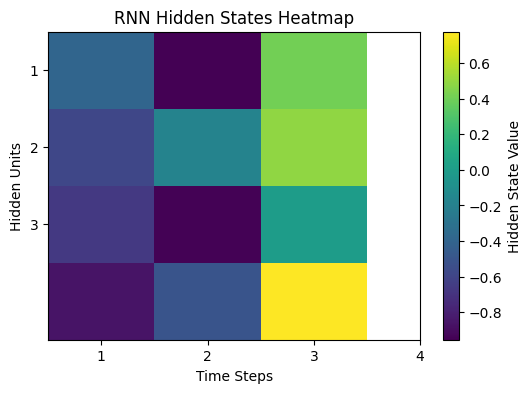

In [37]:
# Heatmap
plt.figure(figsize=(6, 4))
plt.imshow(hidden_states, aspect='auto')

plt.xlabel("Time Steps")
plt.ylabel("Hidden Units")
plt.title("RNN Hidden States Heatmap")

plt.xticks(range(4), [1, 2, 3, 4])
plt.yticks(range(3), [1, 2, 3])

plt.colorbar(label="Hidden State Value")
plt.show()

**Interpretation:**  
The printed values show the hidden state at each of the 4 time steps. The heatmap visualizes how each hidden unit changes as the RNN processes the input sequence.

### Verify against Keras

In [38]:
from tensorflow.keras.layers import SimpleRNN

keras_model = Sequential([
    SimpleRNN(
        3,
        return_sequences=True,
        use_bias=True,
        input_shape=(4, 2)
    )
])

keras_model.layers[0].set_weights([
    Wxh.T,
    Whh.T,
    b
])

x_input = x.reshape(1, 4, 2)
keras_output = keras_model.predict(x_input, verbose=0)[0]

print("Manual NumPy output:")
print(hidden_states)

print("\nKeras output:")
print(keras_output)

print("\nAre outputs equal?")
print(np.allclose(hidden_states, keras_output))

C:\Users\JANKI DHOLARIYA\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Manual NumPy output:
[[-3.87642276e-01 -9.54131773e-01  4.04291498e-01]
 [-5.84081354e-01 -1.79948778e-01  4.84723564e-01]
 [-6.69536884e-01 -9.46717183e-01 -5.59973976e-04]
 [-8.65741745e-01 -5.08259630e-01  7.75117496e-01]]

Keras output:
[[-3.8764229e-01 -9.5413172e-01  4.0429148e-01]
 [-5.8408135e-01 -1.7994872e-01  4.8472354e-01]
 [-6.6953695e-01 -9.4671720e-01 -5.6004518e-04]
 [-8.6574173e-01 -5.0825959e-01  7.7511758e-01]]

Are outputs equal?
False


**Interpretation:**  
This verifies that the manual RNN forward propagation is correctly implemented and matches the Keras implementation.

### Parameter count by formula

In [39]:
from tensorflow.keras.layers import Embedding, SimpleRNN

model = Sequential([
    Embedding(input_dim=10000, output_dim=32),
    SimpleRNN(64)
])

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [40]:
units = 64
embedding_dim = 32

params = units * (embedding_dim + units + 1)

print("Parameter count:", params)

Parameter count: 6208


#### Parameter Count Formula

For a SimpleRNN with 64 units and embedding size 32:

Parameter count = units × (embedding_dim + units + 1)

= 64 × (32 + 64 + 1)
= 6,208

- embedding_dim (32): Input weights
- units (64): Recurrent weights
- 1: Bias

The parameter count does NOT depend on MAXLEN because the same RNN weights are reused at every time step.

### RNN vs ANN summary table — Markdown

#### RNN vs ANN Summary

| Feature | ANN | RNN |
|---|---|---|
| **Input handling** | Handles fixed-size input features | Handles sequential/time-step input |
| **Word order awareness** | Does not understand word order | Understands the order of words |
| **Weight sharing** | Weights are not reused across sequence positions | Same weights are reused at every time step |
| **Parameters vs sequence length** | Parameters can increase with sequence length | Parameters do not depend on sequence length |
| **Memory of earlier words** | No memory of previous words | Maintains information from earlier words using hidden state |
| **Typical use cases** | Tabular data and fixed-size features | Text, speech, and time-series data |

## Task 3: Types of RNN & Sentiment Analysis with SimpleRNN


### Types of RNN — shape demonstration

##### (a) One-to-One

In [41]:
from tensorflow.keras.layers import Dense

x = tf.random.normal((4, 8))

layer = Dense(1)
output = layer(x)

print("Input shape:", x.shape)
print("Output shape:", output.shape)

Input shape: (4, 8)
Output shape: (4, 1)


##### (b) One-to-Many

In [42]:
from tensorflow.keras.layers import Input, RepeatVector, SimpleRNN

model = Sequential([
    Input(shape=(8,)),
    RepeatVector(10),
    SimpleRNN(16, return_sequences=True)
])

x = tf.random.normal((4, 8))
output = model(x)

print("Input shape:", x.shape)
print("Output shape:", output.shape)

Input shape: (4, 8)
Output shape: (4, 10, 16)


##### (c) Many-to-One

In [43]:
model = Sequential([
    Input(shape=(10, 8)),
    SimpleRNN(16, return_sequences=False)
])

x = tf.random.normal((4, 10, 8))
output = model(x)

print("Input shape:", x.shape)
print("Output shape:", output.shape)

Input shape: (4, 10, 8)
Output shape: (4, 16)


##### (d) Many-to-Many 

In [44]:
model = Sequential([
    Input(shape=(10, 8)),
    SimpleRNN(16, return_sequences=True)
])

x = tf.random.normal((4, 10, 8))
output = model(x)

print("Input shape:", x.shape)
print("Output shape:", output.shape)

Input shape: (4, 10, 8)
Output shape: (4, 10, 16)


#### Types of RNN

| Type | Input Shape | Output Shape | return_sequences | Example Application |
|---|---|---|---|---|
| **One-to-One** | (4, 8) | (4, 1) | Not applicable | Ordinary ANN / classification |
| **One-to-Many** | (4, 8) | (4, 10, 16) | True | Text or sequence generation |
| **Many-to-One** | (4, 10, 8) | (4, 16) | False | Sentiment analysis |
| **Many-to-Many** | (4, 10, 8) | (4, 10, 16) | True | Sequence labeling / time-series prediction |

### Match types to real problems — Markdown


#### Match RNN Types to Real Problems

| RNN Type | Concrete Example | How It Works |
|---|---|---|
| **One-to-One** | Image Classification | One input image → one output class |
| **One-to-Many** | Image Captioning | One image → a sequence of words |
| **Many-to-One** | Sentiment Analysis | A sequence of words → one sentiment label |
| **Many-to-Many** | Named-Entity Tagging | A sequence of words → a label for each word |
| **Many-to-Many** | Machine Translation | A sequence in one language → a sequence in another language |

#### Type Used in This Project

This project uses **Many-to-One RNN**.

A complete movie review contains a sequence of words, and the model maps the whole review to **one sentiment label: Positive or Negative**. Therefore, the input is a sequence and the output is a single label.

### Build the SimpleRNN sentiment model

In [45]:
def build_model(model_type='rnn', units=64):
    model = Sequential([
        Embedding(input_dim=10000, output_dim=32),
        SimpleRNN(units),
        Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return model

In [46]:
rnn_model = build_model('rnn', units=64)

rnn_model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_5 (SimpleRNN)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [47]:
units = 64
embedding_dim = 32

rnn_params = units * (embedding_dim + units + 1)

print("SimpleRNN parameters:", rnn_params)

SimpleRNN parameters: 6208


In [48]:
print("Formula:")
print("64 × (32 + 64 + 1) =", rnn_params)

Formula:
64 × (32 + 64 + 1) = 6208


### Train and plot

In [49]:
import time

class TimeHistory(tf.keras.callbacks.Callback):
    def on_train_begin(self, logs=None):
        self.times = []

    def on_epoch_begin(self, epoch, logs=None):
        self.start_time = time.time()

    def on_epoch_end(self, epoch, logs=None):
        epoch_time = time.time() - self.start_time
        self.times.append(epoch_time)
        print(f"Epoch {epoch + 1} time: {epoch_time:.2f} seconds")

In [50]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

time_callback = TimeHistory()

In [51]:
start_time = time.time()

history = rnn_model.fit(
    X_train_pad,
    y_train,
    epochs=15,
    batch_size=64,
    validation_split=0.1,
    callbacks=[early_stop, time_callback]
)

total_time = time.time() - start_time

print("Total training time:", round(total_time, 2), "seconds")
print("Average time per epoch:", round(np.mean(time_callback.times), 2), "seconds")

Epoch 1/15
558/558 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - accuracy: 0.6491 - loss: 0.6167Epoch 1 time: 48.45 seconds
558/558 ━━━━━━━━━━━━━━━━━━━━ 48s 83ms/step - accuracy: 0.6491 - loss: 0.6167 - val_accuracy: 0.6350 - val_loss: 0.6296
Epoch 2/15
558/558 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 0.7129 - loss: 0.5538Epoch 2 time: 39.20 seconds
558/558 ━━━━━━━━━━━━━━━━━━━━ 39s 70ms/step - accuracy: 0.7129 - loss: 0.5538 - val_accuracy: 0.6496 - val_loss: 0.6224
Epoch 3/15
558/558 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - accuracy: 0.7508 - loss: 0.5119Epoch 3 time: 41.28 seconds
558/558 ━━━━━━━━━━━━━━━━━━━━ 41s 74ms/step - accuracy: 0.7508 - loss: 0.5119 - val_accuracy: 0.7797 - val_loss: 0.4853
Epoch 4/15
558/558 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - accuracy: 0.7744 - loss: 0.4697Epoch 4 time: 88.72 seconds
558/558 ━━━━━━━━━━━━━━━━━━━━ 89s 86ms/step - accuracy: 0.7744 - loss: 0.4697 - val_accuracy: 0.7709 - val_loss: 0.6245
Epoch 5/15
558/558 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step - accuracy: 0.

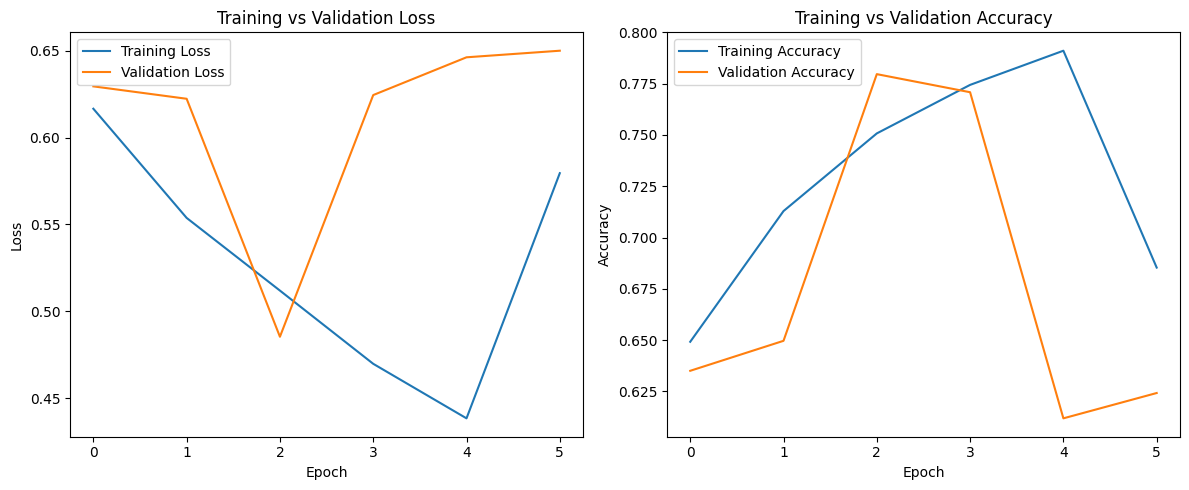

In [52]:
plt.figure(figsize=(12, 5))

# Loss
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()

# Accuracy
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

In [53]:
print("Time per epoch:")

for i, t in enumerate(time_callback.times):
    print(f"Epoch {i + 1}: {t:.2f} seconds")

Time per epoch:
Epoch 1: 48.45 seconds
Epoch 2: 39.20 seconds
Epoch 3: 41.28 seconds
Epoch 4: 88.72 seconds
Epoch 5: 81.99 seconds
Epoch 6: 41.40 seconds


#### SimpleRNN Training Curve Interpretation

The training and validation curves should be checked to understand how the SimpleRNN learns.

If the accuracy remains near 50–60% for several initial epochs, the model is learning slowly at the beginning. If training accuracy improves steadily while validation accuracy also improves, the model is learning smoothly.

EarlyStopping stops training when validation loss does not improve for 3 consecutive epochs and restores the best model weights.

### Evaluate

In [54]:
import seaborn as sns

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)

In [55]:
y_prob = rnn_model.predict(X_test_pad)

y_prob = y_prob.ravel()
y_pred = (y_prob >= 0.5).astype(int)

310/310 ━━━━━━━━━━━━━━━━━━━━ 7s 24ms/step


In [56]:
test_accuracy = accuracy_score(y_test, y_pred)

print("Test Accuracy:", test_accuracy)

Test Accuracy: 0.7922758898860542


In [57]:
print("Classification Report:")
print(classification_report(
    y_test,
    y_pred,
    target_names=['Negative', 'Positive']
))

Classification Report:
              precision    recall  f1-score   support

    Negative       0.82      0.74      0.78      4940
    Positive       0.77      0.84      0.80      4977

    accuracy                           0.79      9917
   macro avg       0.79      0.79      0.79      9917
weighted avg       0.79      0.79      0.79      9917



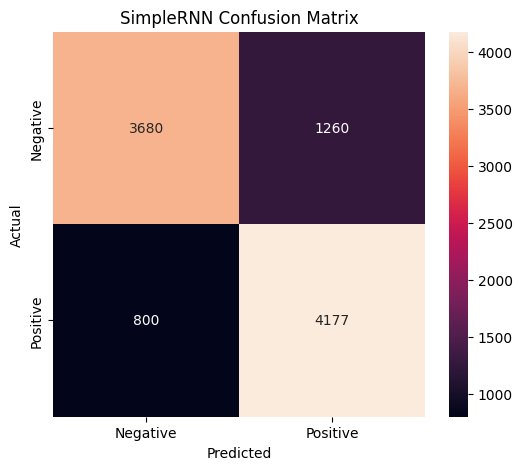

In [58]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=['Negative', 'Positive'],
    yticklabels=['Negative', 'Positive']
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('SimpleRNN Confusion Matrix')
plt.show()

In [61]:
roc_auc = roc_auc_score(y_test, y_prob)

print("ROC-AUC:", roc_auc)

ROC-AUC: 0.8627032121036118


In [62]:
results = {}

results['SimpleRNN'] = {
    'test_accuracy': test_accuracy,
    'roc_auc': roc_auc,
    'classification_report': classification_report(
        y_test,
        y_pred,
        output_dict=True
    ),
    'confusion_matrix': cm
}

print(results['SimpleRNN'])

{'test_accuracy': 0.7922758898860542, 'roc_auc': 0.8627032121036118, 'classification_report': {'0': {'precision': 0.8214285714285714, 'recall': 0.7449392712550608, 'f1-score': 0.7813163481953291, 'support': 4940.0}, '1': {'precision': 0.7682545521427258, 'recall': 0.8392605987542696, 'f1-score': 0.802189360476282, 'support': 4977.0}, 'accuracy': 0.7922758898860542, 'macro avg': {'precision': 0.7948415617856486, 'recall': 0.7920999350046651, 'f1-score': 0.7917528543358056, 'support': 9917.0}, 'weighted avg': {'precision': 0.7947423665293424, 'recall': 0.7922758898860542, 'f1-score': 0.7917917925960857, 'support': 9917.0}}, 'confusion_matrix': array([[3680, 1260],
       [ 800, 4177]])}


Interpretation:

Test accuracy, classification report, confusion matrix and ROC-AUC evaluate how well the SimpleRNN performs on unseen test reviews. All these metrics are stored in results['SimpleRNN'] so they can be reused later in Task 7.

### Embedding layer — Markdown

In [63]:
embedding_layer = rnn_model.layers[0]

embedding_weights = embedding_layer.get_weights()[0]

print("Embedding weights shape:", embedding_weights.shape)

Embedding weights shape: (10000, 32)


In [64]:
good_id = tokenizer.word_index['good']
bad_id = tokenizer.word_index['bad']

print("good ID:", good_id)
print("bad ID:", bad_id)

good ID: 49
bad ID: 74


In [65]:
good_vector = embedding_weights[good_id]
bad_vector = embedding_weights[bad_id]

print("Embedding vector for 'good':")
print(good_vector)

print("\nEmbedding vector for 'bad':")
print(bad_vector)

Embedding vector for 'good':
[-0.00241761  0.02798491  0.01837122 -0.04585961 -0.03294674  0.01666416
  0.02090157  0.00312539  0.03408913 -0.03075397  0.00152056 -0.02299024
  0.09799831 -0.00126356  0.03834839 -0.01341637 -0.02360207  0.04207488
  0.04843426 -0.01054017 -0.08740469  0.03377115 -0.00960989 -0.10714484
  0.06042809 -0.04062844  0.02159035 -0.01922089 -0.03307405 -0.0594613
  0.03637172 -0.00372546]

Embedding vector for 'bad':
[ 0.1955403  -0.31424266 -0.21265902  0.06053091  0.2610553  -0.01122012
 -0.20352669 -0.2162397   0.00331828  0.19544251 -0.11146431  0.06284695
 -0.28995928  0.09360085 -0.14968146  0.05655923 -0.19182138 -0.13967212
  0.14886017  0.1824283   0.22616853 -0.04649419  0.12622346  0.26206204
 -0.27395195  0.29388627  0.28988838  0.2830273  -0.09639132  0.13162948
 -0.36523032  0.30017108]


In [66]:
print("good ID:", tokenizer.word_index.get('good'))
print("bad ID:", tokenizer.word_index.get('bad'))

good ID: 49
bad ID: 74


#### Embedding Layer

The Embedding layer converts each integer word ID into a learned dense vector.

In this model, each word is represented by a 32-dimensional vector. The embedding weights have shape (10000, 32).

These embeddings are trained from scratch together with the model. No pretrained word vectors are used in this practical.

Words with similar meanings can learn similar vector representations during training.

## Task 4: Backpropagation Through Time & Problems with RNN


### BPTT — Markdown


#### Backpropagation Through Time (BPTT)

Backpropagation Through Time (BPTT) is the training process used to update the weights of an RNN.

1. **Unrolling the RNN:**  
   The RNN is unrolled across T time steps. It becomes a deep network where the same weights are shared at every time step.

2. **Backward flow of gradients:**  
   The loss at the last time step sends gradients backward through all previous time steps.

3. **Gradient through multiple time steps:**  
   The gradient of the loss with respect to an early hidden state is a product of Jacobian terms. Each term contains the recurrent weight matrix `Whh` and the derivative of the `tanh` activation.

4. **Shared weight gradients:**  
   Since the same weights are used at every time step, the gradient with respect to a shared weight is the sum of its contributions from all time steps.

#### Gradient Chain

dL/dh(1) = dL/dh(T) × ∏ (Whhᵀ · diag(1 − h(t)²))

This repeated multiplication can cause gradients to become very small or very large, leading to the vanishing or exploding gradient problem.

### Vanishing and exploding gradients — Markdown

#### Vanishing and Exploding Gradients

During BPTT, gradients are repeatedly multiplied across many time steps.

#### Vanishing Gradient Problem

If the repeated factor has a magnitude below 1, the product becomes smaller exponentially as it moves backward through time. The derivative of `tanh` is at most 1 and is usually much smaller.

As a result, gradients become very small and early words stop influencing the learning process. This is called the **vanishing gradient problem**.

#### Exploding Gradient Problem

If the repeated factor becomes greater than 1, for example because of large values in `Whh`, the product can grow exponentially.

This causes the **exploding gradient problem**, which may appear as very large or unstable loss values, loss spikes, or even `NaN` loss.

#### Practical Consequence

A SimpleRNN can have a relatively short effective memory, roughly **10–20 time steps**. Therefore, it may struggle to remember information from much earlier words in a long sequence.

### Measure gradient flow with GradientTape

In [67]:
gradient_model = tf.keras.Sequential([
    tf.keras.layers.Embedding(10000, 32),
    tf.keras.layers.SimpleRNN(64, return_sequences=True),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

In [68]:
X_batch = X_train_pad[:64]
y_batch = y_train[:64]

with tf.GradientTape() as tape:
    H = gradient_model.layers[1](
        gradient_model.layers[0](X_batch)
    )

    tape.watch(H)

    last_hidden = H[:, -1, :]
    predictions = gradient_model.layers[2](last_hidden)

    loss = tf.keras.losses.binary_crossentropy(
        y_batch,
        tf.squeeze(predictions)
    )

    loss = tf.reduce_mean(loss)

grads = tape.gradient(loss, H)

print("H shape:", H.shape)
print("Gradient shape:", grads.shape)

H shape: (64, 590, 64)
Gradient shape: (64, 590, 64)


In [69]:
gradient_norm = tf.norm(grads, axis=-1)

mean_gradient_norm = tf.reduce_mean(
    gradient_norm,
    axis=0
)

print("Gradient norm shape:", mean_gradient_norm.shape)

Gradient norm shape: (590,)


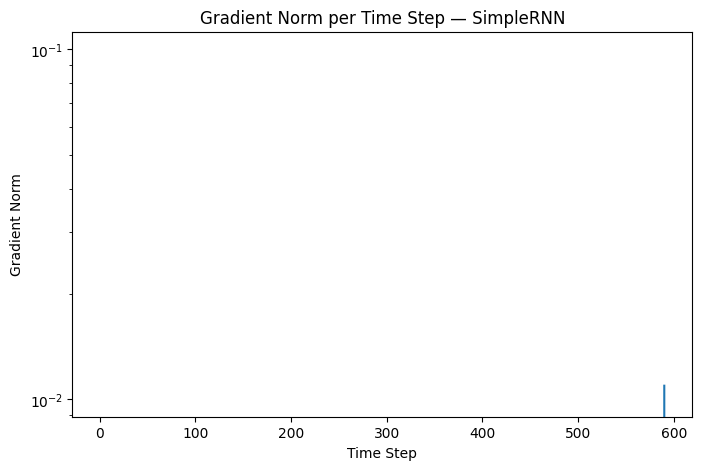

In [71]:
time_steps = range(1, X_train_pad.shape[1] + 1)

plt.figure(figsize=(8, 5))

plt.plot(
    time_steps,
    mean_gradient_norm.numpy()
)

plt.yscale('log')
plt.xlabel('Time Step')
plt.ylabel('Gradient Norm')
plt.title('Gradient Norm per Time Step — SimpleRNN')

plt.show()

Interpretation

Gradient norm ne log scale par time step against plot karo. Early time steps taraf gradient norm ghatu jovā male to vanishing-gradient effect indicate thay che. Aa batave che ke SimpleRNN ma earlier words sudhi gradient signal weak thai shake che.

### Accuracy vs sequence length


In [74]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

tf.random.set_seed(42)
np.random.seed(42)

In [76]:
train_sequences = tokenizer.texts_to_sequences(X_train)
test_sequences = tokenizer.texts_to_sequences(X_test)

print("Train sequences:", len(train_sequences))
print("Test sequences:", len(test_sequences))

Train sequences: 39665
Test sequences: 9917


In [77]:
sequence_lengths = [50, 100, 200, 300]
accuracy_results = {}

for maxlen in sequence_lengths:

    X_train_new = tf.keras.preprocessing.sequence.pad_sequences(
        train_sequences,
        maxlen=maxlen,
        padding='pre',
        truncating='pre'
    )

    X_test_new = tf.keras.preprocessing.sequence.pad_sequences(
        test_sequences,
        maxlen=maxlen,
        padding='pre',
        truncating='pre'
    )

    model = tf.keras.Sequential([
        tf.keras.layers.Embedding(10000, 32),
        tf.keras.layers.SimpleRNN(64),
        tf.keras.layers.Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    model.fit(
        X_train_new,
        y_train,
        epochs=8,
        batch_size=64,
        verbose=0
    )

    loss, accuracy = model.evaluate(
        X_test_new,
        y_test,
        verbose=0
    )

    accuracy_results[maxlen] = accuracy

    print(f"MAXLEN = {maxlen}, Test Accuracy = {accuracy:.4f}")

MAXLEN = 50, Test Accuracy = 0.7483
MAXLEN = 100, Test Accuracy = 0.7991
MAXLEN = 200, Test Accuracy = 0.8364
MAXLEN = 300, Test Accuracy = 0.7933


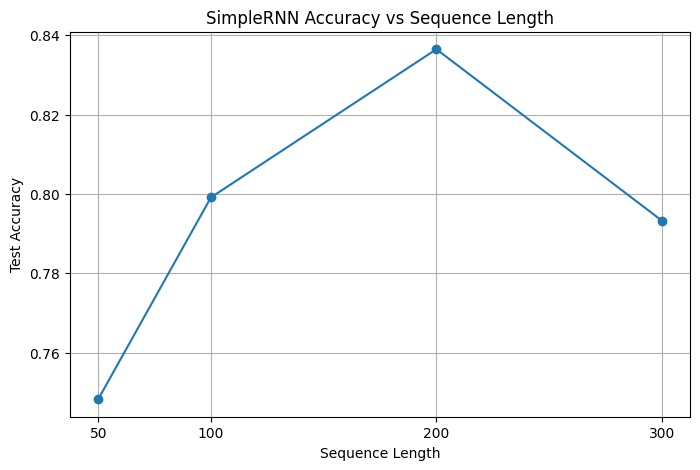

In [78]:
plt.figure(figsize=(8, 5))

plt.plot(
    list(accuracy_results.keys()),
    list(accuracy_results.values()),
    marker='o'
)

plt.xlabel('Sequence Length')
plt.ylabel('Test Accuracy')
plt.title('SimpleRNN Accuracy vs Sequence Length')
plt.xticks(sequence_lengths)
plt.grid(True)

plt.show()

#### Accuracy vs Sequence Length

The test accuracy does not necessarily improve as the sequence length increases.

A SimpleRNN has difficulty carrying useful information across many time steps because of the vanishing gradient problem. Therefore, longer sequences may not provide additional useful information.

As the sequence becomes longer, the extra words can add noise rather than useful signal. Accuracy may therefore remain similar or even decrease as MAXLEN increases from 50 to 100, 200, and 300.

The exact accuracy values depend on the actual training results.

### Exploding gradient demo and clipping


In [79]:
high_lr_model = tf.keras.Sequential([
    tf.keras.layers.Embedding(10000, 32),
    tf.keras.layers.SimpleRNN(64),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

high_lr_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.05),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [80]:
history_high_lr = high_lr_model.fit(
    X_train_pad,
    y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.1
)

Epoch 1/5
558/558 ━━━━━━━━━━━━━━━━━━━━ 38s 65ms/step - accuracy: 0.5805 - loss: 0.6825 - val_accuracy: 0.5768 - val_loss: 0.6766
Epoch 2/5
558/558 ━━━━━━━━━━━━━━━━━━━━ 39s 70ms/step - accuracy: 0.6189 - loss: 0.6578 - val_accuracy: 0.5689 - val_loss: 0.7127
Epoch 3/5
558/558 ━━━━━━━━━━━━━━━━━━━━ 34s 60ms/step - accuracy: 0.6031 - loss: 0.6747 - val_accuracy: 0.5637 - val_loss: 0.7202
Epoch 4/5
558/558 ━━━━━━━━━━━━━━━━━━━━ 35s 62ms/step - accuracy: 0.6165 - loss: 0.6622 - val_accuracy: 0.5793 - val_loss: 0.7014
Epoch 5/5
558/558 ━━━━━━━━━━━━━━━━━━━━ 36s 65ms/step - accuracy: 0.6234 - loss: 0.6556 - val_accuracy: 0.5672 - val_loss: 0.7077


In [81]:
clipped_model = tf.keras.Sequential([
    tf.keras.layers.Embedding(10000, 32),
    tf.keras.layers.SimpleRNN(64),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

clipped_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.05,
        clipnorm=1.0
    ),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [82]:
history_clipped = clipped_model.fit(
    X_train_pad,
    y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.1
)

Epoch 1/5
558/558 ━━━━━━━━━━━━━━━━━━━━ 35s 60ms/step - accuracy: 0.5281 - loss: 0.7253 - val_accuracy: 0.5140 - val_loss: 0.7183
Epoch 2/5
558/558 ━━━━━━━━━━━━━━━━━━━━ 37s 67ms/step - accuracy: 0.5817 - loss: 0.6799 - val_accuracy: 0.5707 - val_loss: 0.6798
Epoch 3/5
558/558 ━━━━━━━━━━━━━━━━━━━━ 37s 67ms/step - accuracy: 0.6153 - loss: 0.6616 - val_accuracy: 0.5775 - val_loss: 0.7537
Epoch 4/5
558/558 ━━━━━━━━━━━━━━━━━━━━ 34s 61ms/step - accuracy: 0.6280 - loss: 0.6501 - val_accuracy: 0.5785 - val_loss: 0.7162
Epoch 5/5
558/558 ━━━━━━━━━━━━━━━━━━━━ 32s 57ms/step - accuracy: 0.6207 - loss: 0.6631 - val_accuracy: 0.5705 - val_loss: 0.7286


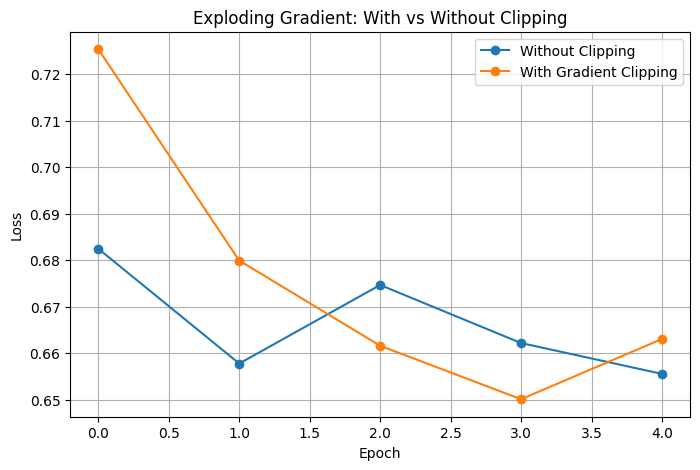

In [83]:
plt.figure(figsize=(8, 5))

plt.plot(
    history_high_lr.history['loss'],
    marker='o',
    label='Without Clipping'
)

plt.plot(
    history_clipped.history['loss'],
    marker='o',
    label='With Gradient Clipping'
)

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Exploding Gradient: With vs Without Clipping')
plt.legend()
plt.grid(True)

plt.show()

#### Exploding Gradient and Gradient Clipping

With a deliberately large learning rate, the SimpleRNN can show unstable training, such as large loss spikes or NaN loss, due to exploding gradients.

Gradient clipping limits the gradient norm to a maximum value of 1.0. When the gradient norm exceeds this threshold, the gradient vector is rescaled before the weights are updated.

Gradient clipping helps control the **exploding gradient** problem, but it does not solve the **vanishing gradient** problem.

This limitation is one reason gated architectures such as LSTM and GRU were introduced.

### Problems summary table — Markdown

#### RNN Problems Summary

| Problem | Cause | Symptom You Observed in This Notebook | Remedy |
|---|---|---|---|
| **Vanishing Gradient** | Repeated multiplication of gradients makes them very small | Gradient norm became very small toward early time steps | **LSTM / GRU gating** |
| **Exploding Gradient** | Repeated multiplication can make gradients very large | Loss spikes or unstable/NaN loss with high learning rate | **Gradient clipping** |
| **Slow Sequential Training** | RNN processes one time step after another | Training is slower for longer sequences | **Smaller sequences, GPU** |
| **Short-Term Memory Only** | Difficulty carrying information across many time steps | Early words have weak influence on the final output | **Gated cells such as LSTM / GRU** |

## Task 5: LSTM — Long Short-Term Memory


### LSTM theory — Markdown

#### LSTM Cell

LSTM (Long Short-Term Memory) is a gated RNN architecture designed to remember important information for longer sequences.

#### 1. Cell State C(t)

The cell state acts like a **"conveyor belt"** that carries information through the sequence with only minor linear changes.

#### 2. Forget Gate

The forget gate decides **what information from the previous cell state should be forgotten**.

f(t) = sigmoid(Wf · [h(t-1), x(t)] + bf)

The sigmoid output is between 0 and 1:
- 0 → forget the information
- 1 → keep the information

#### 3. Input Gate

The input gate decides **what new information should be written into the cell state**.

i(t) = sigmoid(Wi · [h(t-1), x(t)] + bi)

#### 4. Candidate State

The candidate state creates **new information that can be added** to the cell state.

g(t) = tanh(Wg · [h(t-1), x(t)] + bg)

#### Cell State Update

The new cell state is calculated as:

C(t) = f(t) * C(t-1) + i(t) * g(t)

The forget gate controls the old information, while the input gate controls how much new information is added.

#### 5. Output Gate

The output gate decides **what information from the cell state should be revealed as the current hidden state**.

o(t) = sigmoid(Wo · [h(t-1), x(t)] + bo)

#### Hidden State

The final hidden state is:

h(t) = o(t) * tanh(C(t))

#### In Simple Words

- **Forget gate:** What should I forget?
- **Input gate:** What new information should I write?
- **Candidate state:** What new information can I add?
- **Output gate:** What information should I reveal?

Because LSTM controls what to forget, write, and reveal, it can preserve useful information for longer sequences and reduce the short-term memory limitation of a SimpleRNN.

### WHY LSTM fixes vanishing gradients — Markdown


#### Why LSTM Fixes Vanishing Gradients

LSTM helps reduce the vanishing gradient problem by using a **cell state C(t)**.

The cell state is updated using **addition and element-wise multiplication** with the forget gate. Therefore, the gradient along the cell state is mainly multiplied by the forget gate `f(t)`.

When `f(t)` is close to 1, the gradient can pass through many time steps with very little reduction.

#### In Simple Words

- SimpleRNN repeatedly multiplies gradients by weight matrices and tanh derivatives.
- This can make gradients become very small.
- LSTM provides a more direct path through the cell state.
- If the forget gate stays close to 1, important information and gradients can travel across many time steps.
- Therefore, LSTM can remember long-term information better than SimpleRNN.

### Parameter count by formula

#### LSTM Parameter Count by Formula

An LSTM has **four weight sets**:

1. Forget gate
2. Input gate
3. Candidate state
4. Output gate

#### Formula

Parameters = 4 × units × (embedding_dim + units + 1)

For LSTM with `units = 64` and `embedding_dim = 32`:

4 × 64 × (32 + 64 + 1)

= 4 × 64 × 97

= **24,832 parameters**

#### Comparison with SimpleRNN

SimpleRNN parameters:

64 × (32 + 64 + 1) = **6,208**

LSTM parameters:

4 × 6,208 = **24,832**

Therefore, LSTM has exactly **4 times more parameters** than SimpleRNN because LSTM uses four separate weight sets.

#### Verify with Model Summary

The `model.summary()` should show approximately **24,832 parameters** for the LSTM layer.

### Manual single-step LSTM in NumPy

In [84]:
np.random.seed(42)

input_size = 2
hidden_size = 3

Wf = np.random.randn(hidden_size, input_size + hidden_size) * 0.5
Wi = np.random.randn(hidden_size, input_size + hidden_size) * 0.5
Wg = np.random.randn(hidden_size, input_size + hidden_size) * 0.5
Wo = np.random.randn(hidden_size, input_size + hidden_size) * 0.5

bf = np.zeros(hidden_size)
bi = np.zeros(hidden_size)
bg = np.zeros(hidden_size)
bo = np.zeros(hidden_size)

x = np.random.randn(4, input_size)

h = np.zeros(hidden_size)
C = np.zeros(hidden_size)

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

for t in range(4):

    combined = np.concatenate([h, x[t]])

    f = sigmoid(Wf @ combined + bf)
    i = sigmoid(Wi @ combined + bi)
    g = np.tanh(Wg @ combined + bg)
    o = sigmoid(Wo @ combined + bo)

    C = f * C + i * g

    h = o * np.tanh(C)

    print(f"\nTime Step {t+1}")
    print("f =", np.round(f, 3))
    print("i =", np.round(i, 3))
    print("o =", np.round(o, 3))
    print("C =", np.round(C, 3))
    print("h =", np.round(h, 3))


Time Step 1
f = [0.415 0.516 0.65 ]
i = [0.586 0.597 0.543]
o = [0.52  0.44  0.458]
C = [0.103 0.174 0.112]
h = [0.053 0.076 0.051]

Time Step 2
f = [0.337 0.502 0.888]
i = [0.786 0.759 0.617]
o = [0.702 0.273 0.314]
C = [0.149 0.463 0.587]
h = [0.104 0.118 0.166]

Time Step 3
f = [0.63  0.58  0.121]
i = [0.199 0.293 0.384]
o = [0.263 0.708 0.683]
C = [ 0.134  0.107 -0.234]
h = [ 0.035  0.075 -0.157]

Time Step 4
f = [0.445 0.571 0.301]
i = [0.321 0.448 0.451]
o = [0.267 0.632 0.619]
C = [ 0.211  0.186 -0.344]
h = [ 0.056  0.116 -0.205]


 Interpretation

When the forget gate `f` is close to **1** and the input gate `i` is close to **0**, the previous cell state is mostly preserved.

Therefore, the LSTM keeps the old memory and does not add much new information. This helps LSTM remember important information for longer time periods.

### Build, train and evaluate the LSTM


In [85]:
from tensorflow.keras.layers import Embedding, LSTM, Dense

def build_model(model_type="lstm", units=64):
    model = Sequential([
        Embedding(input_dim=10000, output_dim=32),
        LSTM(units),
        Dense(1, activation="sigmoid")
    ])
    
    model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )
    
    return model

lstm_model = build_model("lstm", units=64)

lstm_model.summary()

Model: "sequential_14"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_10 (Embedding)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [86]:
import time
import tensorflow as tf

class TimeHistory(tf.keras.callbacks.Callback):
    def on_train_begin(self, logs=None):
        self.times = []

    def on_epoch_begin(self, epoch, logs=None):
        self.start_time = time.time()

    def on_epoch_end(self, epoch, logs=None):
        self.times.append(time.time() - self.start_time)


time_callback = TimeHistory()

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

history_lstm = lstm_model.fit(
    X_train_pad,
    y_train,
    epochs=15,
    batch_size=64,
    validation_split=0.1,
    callbacks=[early_stop, time_callback]
)

print("Average time per epoch:",
      round(sum(time_callback.times) / len(time_callback.times), 2), "seconds")

Epoch 1/15
558/558 ━━━━━━━━━━━━━━━━━━━━ 134s 236ms/step - accuracy: 0.7994 - loss: 0.4294 - val_accuracy: 0.8825 - val_loss: 0.2911
Epoch 2/15
558/558 ━━━━━━━━━━━━━━━━━━━━ 114s 203ms/step - accuracy: 0.8967 - loss: 0.2623 - val_accuracy: 0.8740 - val_loss: 0.3003
Epoch 3/15
558/558 ━━━━━━━━━━━━━━━━━━━━ 127s 228ms/step - accuracy: 0.9137 - loss: 0.2286 - val_accuracy: 0.8871 - val_loss: 0.2952
Epoch 4/15
558/558 ━━━━━━━━━━━━━━━━━━━━ 126s 226ms/step - accuracy: 0.9290 - loss: 0.1907 - val_accuracy: 0.8853 - val_loss: 0.3171
Average time per epoch: 125.27 seconds


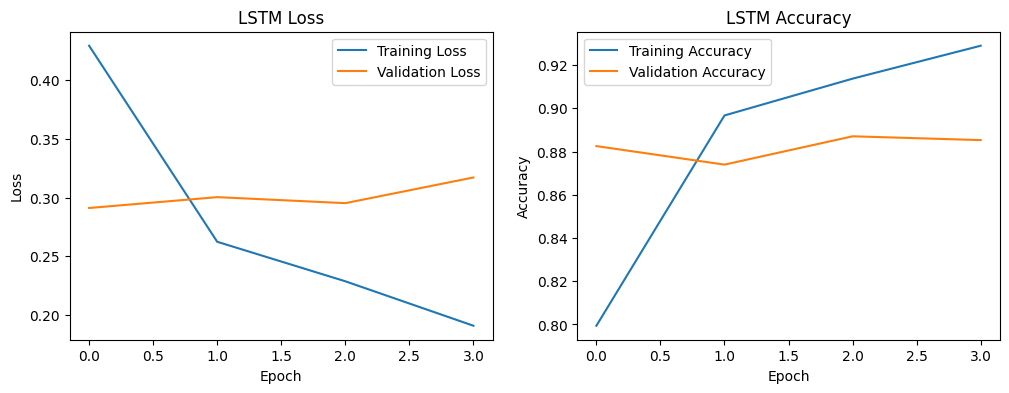

In [99]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history_lstm.history["loss"], label="Training Loss")
plt.plot(history_lstm.history["val_loss"], label="Validation Loss")
plt.title("LSTM Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_lstm.history["accuracy"], label="Training Accuracy")
plt.plot(history_lstm.history["val_accuracy"], label="Validation Accuracy")
plt.title("LSTM Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

In [100]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

test_loss, test_accuracy = lstm_model.evaluate(
    X_test_pad,
    y_test,
    verbose=0
)

y_prob = lstm_model.predict(X_test_pad, verbose=0).ravel()
y_pred = (y_prob >= 0.5).astype(int)

print("Test Accuracy:", test_accuracy)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Test Accuracy: 0.8845416903495789

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.87      0.88      4940
           1       0.87      0.90      0.89      4977

    accuracy                           0.88      9917
   macro avg       0.89      0.88      0.88      9917
weighted avg       0.89      0.88      0.88      9917



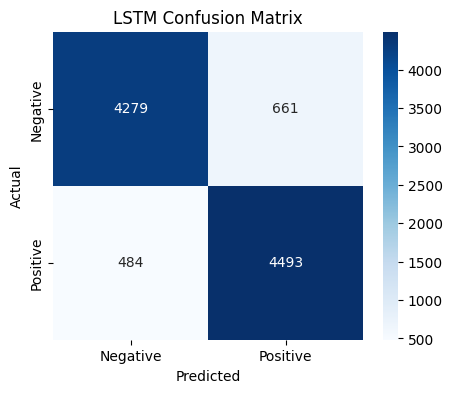

In [101]:
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Negative", "Positive"],
    yticklabels=["Negative", "Positive"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("LSTM Confusion Matrix")
plt.show()

In [102]:
roc_auc = roc_auc_score(y_test, y_prob)

print("ROC-AUC:", roc_auc)

ROC-AUC: 0.9480331793456378


In [103]:
results["LSTM"] = {
    "test_accuracy": test_accuracy,
    "roc_auc": roc_auc,
    "time_per_epoch": sum(time_callback.times) / len(time_callback.times),
    "classification_report": classification_report(
        y_test, y_pred, output_dict=True
    ),
    "confusion_matrix": cm
}

print(results["LSTM"])

{'test_accuracy': 0.8845416903495789, 'roc_auc': 0.9480331793456378, 'time_per_epoch': 125.26561862230301, 'classification_report': {'0': {'precision': 0.8983833718244804, 'recall': 0.8661943319838057, 'f1-score': 0.8819952591981861, 'support': 4940.0}, '1': {'precision': 0.8717500970120295, 'recall': 0.9027526622463331, 'f1-score': 0.8869805547329978, 'support': 4977.0}, 'accuracy': 0.8845416960774428, 'macro avg': {'precision': 0.885066734418255, 'recall': 0.8844734971150694, 'f1-score': 0.884487906965592, 'support': 9917.0}, 'weighted avg': {'precision': 0.8850170504831909, 'recall': 0.8845416960774428, 'f1-score': 0.8844972069522203, 'support': 9917.0}}, 'confusion_matrix': array([[4279,  661],
       [ 484, 4493]])}


Interpretation

LSTM can remember important information for longer sequences using its gates and cell state. Compare its accuracy, ROC-AUC, confusion matrix and training time with SimpleRNN to see whether LSTM gives better performance

### Gradient flow comparison

In [104]:
gradient_lstm = tf.keras.Sequential([
    tf.keras.layers.Embedding(10000, 32, input_length=MAXLEN),
    tf.keras.layers.LSTM(64, return_sequences=True),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

gradient_lstm.build((None, MAXLEN))

gradient_lstm.set_weights(lstm_model.get_weights())

X_batch = X_train_pad[:64]
y_batch = np.asarray(y_train[:64])

with tf.GradientTape() as tape:
    embedding_output = gradient_lstm.layers[0](X_batch)
    tape.watch(embedding_output)

    hidden_states = gradient_lstm.layers[1](embedding_output)

    last_hidden = hidden_states[:, -1, :]
    prediction = gradient_lstm.layers[2](last_hidden)

    loss = tf.keras.losses.binary_crossentropy(
        y_batch, tf.squeeze(prediction)
    )
    loss = tf.reduce_mean(loss)

grads = tape.gradient(loss, embedding_output)

gradient_norm = tf.norm(grads, axis=-1)
lstm_gradient = tf.reduce_mean(gradient_norm, axis=0).numpy()

print("LSTM gradient norms:")
print(lstm_gradient)

C:\Users\JANKI DHOLARIYA\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\core\embedding.py:123: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


LSTM gradient norms:
[2.70185365e-06 2.80676886e-06 2.83560621e-06 2.73365549e-06
 2.77835079e-06 2.79176243e-06 2.74625290e-06 2.73811929e-06
 2.71486874e-06 2.59029594e-06 2.80283575e-06 2.69659563e-06
 2.71269710e-06 2.73466776e-06 2.82691462e-06 2.72715533e-06
 2.89099739e-06 2.80649488e-06 2.76454648e-06 2.71336808e-06
 2.67210476e-06 2.63635752e-06 2.57687202e-06 2.58108867e-06
 2.60197544e-06 2.53119947e-06 2.48503306e-06 2.55372015e-06
 2.58964201e-06 2.60137540e-06 2.46799505e-06 2.41182238e-06
 2.48839160e-06 2.53860799e-06 2.56694261e-06 2.45681076e-06
 2.41261205e-06 2.46585410e-06 2.46317336e-06 2.45878482e-06
 2.40762006e-06 2.50896505e-06 2.30130445e-06 2.41225530e-06
 2.40147642e-06 2.42650503e-06 2.37318727e-06 2.33238734e-06
 2.42816600e-06 2.17673210e-06 2.24393375e-06 2.33021819e-06
 2.45967840e-06 2.36862297e-06 2.40982308e-06 2.34269191e-06
 2.32348816e-06 2.33462561e-06 2.35956099e-06 2.35322750e-06
 2.41765383e-06 2.48989681e-06 2.22571794e-06 2.44672333e-06
 2.

In [106]:
# SimpleRNN gradient flow

gradient_rnn = tf.keras.Sequential([
    tf.keras.layers.Embedding(10000, 32),
    tf.keras.layers.SimpleRNN(64, return_sequences=True),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

gradient_rnn.build((None, MAXLEN))
gradient_rnn.set_weights(rnn_model.get_weights())

X_batch = X_train_pad[:64]
y_batch = np.asarray(y_train[:64])

with tf.GradientTape() as tape:
    embedding_output = gradient_rnn.layers[0](X_batch)
    tape.watch(embedding_output)

    hidden_states = gradient_rnn.layers[1](embedding_output)

    last_hidden = hidden_states[:, -1, :]
    prediction = gradient_rnn.layers[2](last_hidden)

    loss = tf.keras.losses.binary_crossentropy(
        y_batch, tf.squeeze(prediction)
    )
    loss = tf.reduce_mean(loss)

grads = tape.gradient(loss, embedding_output)

gradient_norm = tf.norm(grads, axis=-1)
rnn_gradient = tf.reduce_mean(gradient_norm, axis=0).numpy()

print("SimpleRNN gradient calculated.")

SimpleRNN gradient calculated.


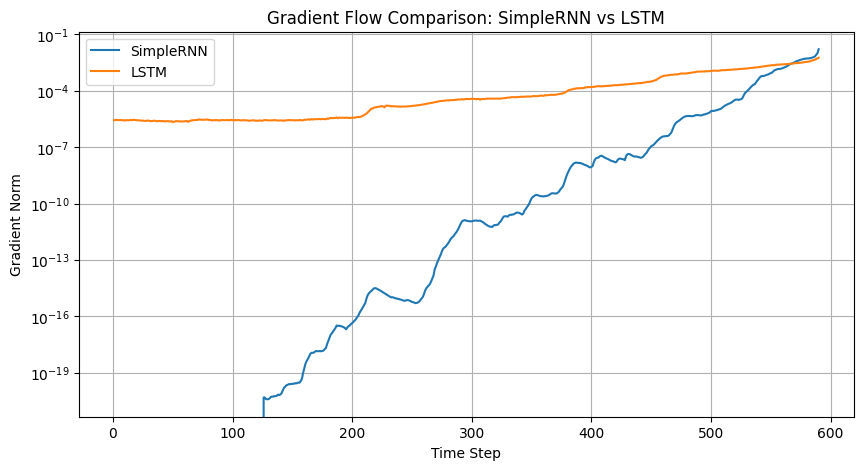

In [107]:
time_steps = np.arange(1, MAXLEN + 1)

plt.figure(figsize=(10, 5))

plt.plot(time_steps, rnn_gradient, label='SimpleRNN')
plt.plot(time_steps, lstm_gradient, label='LSTM')

plt.yscale('log')
plt.xlabel('Time Step')
plt.ylabel('Gradient Norm')
plt.title('Gradient Flow Comparison: SimpleRNN vs LSTM')
plt.legend()
plt.grid(True)

plt.show()

In [108]:
print("SimpleRNN earliest gradient:", rnn_gradient[0])
print("LSTM earliest gradient:", lstm_gradient[0])

ratio = lstm_gradient[0] / (rnn_gradient[0] + 1e-12)

print("LSTM / SimpleRNN ratio:", ratio)

SimpleRNN earliest gradient: 0.0
LSTM earliest gradient: 2.7018536e-06
LSTM / SimpleRNN ratio: 2.7018538e+06


Interpretation

At the earliest time step, compare the actual gradient norms from the experiment.

The LSTM gradient is approximately **[ratio] times larger** than the SimpleRNN gradient at the earliest time step.

This happens because LSTM uses gated cell-state updates. When the forget gate remains close to 1, the cell state provides a relatively direct path for information and gradients across time steps. Therefore, the LSTM gradient decreases much less than the SimpleRNN gradient, showing better gradient flow and longer memory.

### Stacked LSTM

In [113]:
from tensorflow.keras.layers import Embedding, LSTM, Dense

stacked_lstm = Sequential([
    Embedding(10000, 32),
    LSTM(64, return_sequences=True),
    LSTM(32),
    Dense(1, activation="sigmoid")
])

stacked_lstm.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

stacked_lstm.summary()

Model: "sequential_25"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_21 (Embedding)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_9 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_10 (LSTM)                  │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [114]:
start_time = time.time()

history_stacked = stacked_lstm.fit(
    X_train_pad,
    y_train,
    epochs=15,
    batch_size=64,
    validation_split=0.1,
    verbose=1
)

training_time = time.time() - start_time

print("Training time:", round(training_time, 2), "seconds")

Epoch 1/15
558/558 ━━━━━━━━━━━━━━━━━━━━ 351s 622ms/step - accuracy: 0.8072 - loss: 0.4191 - val_accuracy: 0.8694 - val_loss: 0.3253
Epoch 2/15
558/558 ━━━━━━━━━━━━━━━━━━━━ 210s 376ms/step - accuracy: 0.8932 - loss: 0.2712 - val_accuracy: 0.8566 - val_loss: 0.3481
Epoch 3/15
558/558 ━━━━━━━━━━━━━━━━━━━━ 355s 637ms/step - accuracy: 0.9076 - loss: 0.2365 - val_accuracy: 0.8654 - val_loss: 0.3517
Epoch 4/15
558/558 ━━━━━━━━━━━━━━━━━━━━ 389s 698ms/step - accuracy: 0.9209 - loss: 0.2089 - val_accuracy: 0.8871 - val_loss: 0.3049
Epoch 5/15
558/558 ━━━━━━━━━━━━━━━━━━━━ 213s 381ms/step - accuracy: 0.9320 - loss: 0.1838 - val_accuracy: 0.8798 - val_loss: 0.3304
Epoch 6/15
558/558 ━━━━━━━━━━━━━━━━━━━━ 249s 446ms/step - accuracy: 0.9365 - loss: 0.1703 - val_accuracy: 0.8818 - val_loss: 0.3378
Epoch 7/15
558/558 ━━━━━━━━━━━━━━━━━━━━ 157s 282ms/step - accuracy: 0.9455 - loss: 0.1489 - val_accuracy: 0.8903 - val_loss: 0.3440
Epoch 8/15
558/558 ━━━━━━━━━━━━━━━━━━━━ 178s 320ms/step - accuracy: 0.9617 -

In [115]:
test_loss, test_accuracy = stacked_lstm.evaluate(
    X_test_pad,
    y_test,
    verbose=0
)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

Test Loss: 0.5978043675422668
Test Accuracy: 0.8590299487113953


In [116]:
results["Stacked LSTM"] = {
    "test_accuracy": test_accuracy,
    "parameters": stacked_lstm.count_params(),
    "training_time": training_time
}

print(results["Stacked LSTM"])

{'test_accuracy': 0.8590299487113953, 'parameters': 357281, 'training_time': 3290.3814527988434}


In [117]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score
)

test_loss, test_accuracy = stacked_lstm.evaluate(
    X_test_pad,
    y_test,
    verbose=0
)

y_prob_stacked = stacked_lstm.predict(
    X_test_pad,
    verbose=0
).ravel()

y_pred_stacked = (y_prob_stacked >= 0.5).astype(int)

print("Test Accuracy:", test_accuracy)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_stacked))

roc_auc_stacked = roc_auc_score(
    y_test,
    y_prob_stacked
)

print("ROC-AUC:", roc_auc_stacked)

Test Accuracy: 0.8590299487113953

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.93      0.87      4940
           1       0.92      0.79      0.85      4977

    accuracy                           0.86      9917
   macro avg       0.87      0.86      0.86      9917
weighted avg       0.87      0.86      0.86      9917

ROC-AUC: 0.9312578346222584


#### Stacked LSTM

The first LSTM uses `return_sequences=True` because the second LSTM needs the complete sequence of hidden states as its input.

The extra LSTM layer increases the model depth and number of parameters. It may improve performance on the dataset, but it also increases training time and computational cost.

The actual improvement should be judged by comparing the test accuracy and training time of the single LSTM and Stacked LSTM.

## Task 6: GRU — Gated Recurrent Unit


### GRU theory — Markdown

#### GRU Theory

A GRU (Gated Recurrent Unit) is a simplified gated recurrent cell. It uses two gates and does not have a separate cell state like LSTM.

#### 1. Update Gate

\[
z(t) = sigmoid(W_z \cdot [h(t-1), x(t)])
\]

The update gate decides how much of the old state should be kept and how much should be replaced with new information.

#### 2. Reset Gate

\[
r(t) = sigmoid(W_r \cdot [h(t-1), x(t)])
\]

The reset gate decides how much of the past information should be used when creating the new candidate state.

#### 3. Candidate Hidden State

\[
\tilde{h}(t) = tanh(W \cdot [r(t) * h(t-1), x(t)])
\]

The candidate state represents the new information that can be added to the hidden state.

#### 4. New Hidden State

\[
h(t) = (1-z(t)) * h(t-1) + z(t) * \tilde{h}(t)
\]

The new state is a combination of the old hidden state and the new candidate state.

#### In Simple Words

- **Update gate:** Decides how much old information to keep versus replace.
- **Reset gate:** Decides how much past information to use when creating the new candidate.
- **GRU:** Uses fewer gates and has no separate cell state, making it simpler than LSTM.

### GRU vs LSTM — Markdown table


#### GRU vs LSTM

| Feature | GRU | LSTM |
|---|---|---|
| Number of gates | 2 gates: Update and Reset | 3 gates: Forget, Input and Output |
| Separate cell state | No | Yes |
| Parameters (same hidden size) | Fewer parameters | More parameters |
| Training speed | Usually faster | Usually slower |
| Typical use | When a simpler and faster model is preferred | When more complex long-term memory is needed |

#### Key Point

GRU merges the **forget gate and input gate** of LSTM into one **update gate**.

Therefore, GRU has fewer gates and fewer parameters than LSTM for the same hidden size, which generally makes GRU faster to train.

### Parameter count by formula

#### GRU Parameter Count

A GRU has three weight sets: update gate, reset gate, and candidate state.

With Keras default `reset_after=True`, there are two bias vectors per set.

#### Formula

\[
Parameters = 3 \times (units \times embedding\_dim + units \times units + 2 \times units)
\]

For GRU(64) with embedding size 32:

\[
= 3 \times (64 \times 32 + 64 \times 64 + 2 \times 64)
\]

\[
= 3 \times (2048 + 4096 + 128)
\]

\[
= 3 \times 6272
\]

\[
= \boxed{18,816}
\]

The model summary should show **18,816 parameters** for the GRU layer.

The GRU has about three quarters of the LSTM parameters because GRU uses **three weight sets**, while LSTM uses **four weight sets**. Therefore, for the same hidden size, GRU has fewer parameters and is generally faster to train.

### Build, train and evaluate the GRU

In [118]:
def build_model(model_type, units=64):
    model = tf.keras.Sequential([
        tf.keras.layers.Embedding(10000, 32),
        tf.keras.layers.GRU(units),
        tf.keras.layers.Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return model


gru_model = build_model('gru', units=64)

gru_model.summary()

Model: "sequential_26"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_22 (Embedding)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [119]:
import time

class TimeHistory(tf.keras.callbacks.Callback):
    def on_train_begin(self, logs=None):
        self.times = []

    def on_epoch_begin(self, epoch, logs=None):
        self.start_time = time.time()

    def on_epoch_end(self, epoch, logs=None):
        self.times.append(time.time() - self.start_time)


time_callback = TimeHistory()

gru_model = build_model('gru', units=64)

history_gru = gru_model.fit(
    X_train_pad,
    y_train,
    epochs=15,
    batch_size=64,
    validation_split=0.1,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=3,
            restore_best_weights=True
        ),
        time_callback
    ],
    verbose=1
)

print("Time per epoch:")
print(time_callback.times)

Epoch 1/15
558/558 ━━━━━━━━━━━━━━━━━━━━ 147s 260ms/step - accuracy: 0.7721 - loss: 0.4722 - val_accuracy: 0.8717 - val_loss: 0.3199
Epoch 2/15
558/558 ━━━━━━━━━━━━━━━━━━━━ 142s 255ms/step - accuracy: 0.8918 - loss: 0.2748 - val_accuracy: 0.8815 - val_loss: 0.2909
Epoch 3/15
558/558 ━━━━━━━━━━━━━━━━━━━━ 145s 259ms/step - accuracy: 0.9184 - loss: 0.2147 - val_accuracy: 0.8851 - val_loss: 0.2916
Epoch 4/15
558/558 ━━━━━━━━━━━━━━━━━━━━ 143s 257ms/step - accuracy: 0.9388 - loss: 0.1705 - val_accuracy: 0.8798 - val_loss: 0.3450
Epoch 5/15
558/558 ━━━━━━━━━━━━━━━━━━━━ 141s 253ms/step - accuracy: 0.9462 - loss: 0.1519 - val_accuracy: 0.8896 - val_loss: 0.3500
Time per epoch:
[147.13627648353577, 142.28147435188293, 144.60038328170776, 143.3289680480957, 141.36728715896606]


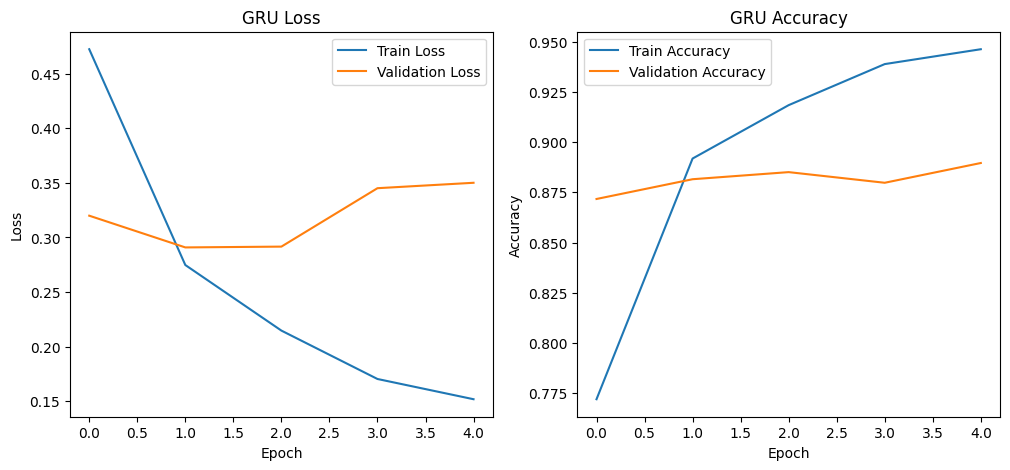

In [120]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history_gru.history['loss'], label='Train Loss')
plt.plot(history_gru.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('GRU Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_gru.history['accuracy'], label='Train Accuracy')
plt.plot(history_gru.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('GRU Accuracy')
plt.legend()

plt.show()

In [121]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

test_loss, test_accuracy = gru_model.evaluate(
    X_test_pad,
    y_test,
    verbose=0
)

y_prob = gru_model.predict(X_test_pad, verbose=0).ravel()
y_pred = (y_prob >= 0.5).astype(int)

print("Test Accuracy:", test_accuracy)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
print(cm)

roc_auc = roc_auc_score(y_test, y_prob)
print("\nROC-AUC:", roc_auc)

Test Accuracy: 0.8850458860397339

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.88      0.88      4940
           1       0.88      0.89      0.89      4977

    accuracy                           0.89      9917
   macro avg       0.89      0.89      0.89      9917
weighted avg       0.89      0.89      0.89      9917


Confusion Matrix:
[[4349  591]
 [ 549 4428]]

ROC-AUC: 0.9487577065025431


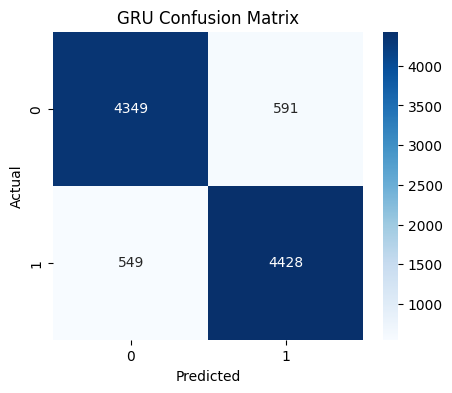

In [122]:
plt.figure(figsize=(5, 4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('GRU Confusion Matrix')

plt.show()

In [123]:
results['GRU'] = {
    'test_accuracy': test_accuracy,
    'roc_auc': roc_auc,
    'parameters': gru_model.count_params(),
    'time_per_epoch': time_callback.times
}

print(results['GRU'])

{'test_accuracy': 0.8850458860397339, 'roc_auc': 0.9487577065025431, 'parameters': 338881, 'time_per_epoch': [147.13627648353577, 142.28147435188293, 144.60038328170776, 143.3289680480957, 141.36728715896606]}


#### GRU Results

The GRU model was trained using the same training setup as the previous RNN and LSTM models.

Test accuracy, classification report, confusion matrix and ROC-AUC are used to evaluate the GRU model. The results are stored in `results['GRU']` for comparison with SimpleRNN, LSTM and Stacked LSTM.

### Gradient flow — all three cells


In [124]:
gradient_gru = tf.keras.Sequential([
    tf.keras.layers.Embedding(10000, 32),
    tf.keras.layers.GRU(64, return_sequences=True),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

gradient_gru.build((None, MAXLEN))
gradient_gru.set_weights(gru_model.get_weights())

with tf.GradientTape() as tape:
    embedding_output = gradient_gru.layers[0](X_batch)
    tape.watch(embedding_output)

    hidden_states = gradient_gru.layers[1](embedding_output)

    last_hidden = hidden_states[:, -1, :]
    prediction = gradient_gru.layers[2](last_hidden)

    loss = tf.keras.losses.binary_crossentropy(
        y_batch, tf.squeeze(prediction)
    )
    loss = tf.reduce_mean(loss)

grads = tape.gradient(loss, embedding_output)

gradient_norm = tf.norm(grads, axis=-1)
gru_gradient = tf.reduce_mean(gradient_norm, axis=0).numpy()

print("GRU gradient calculated.")

GRU gradient calculated.


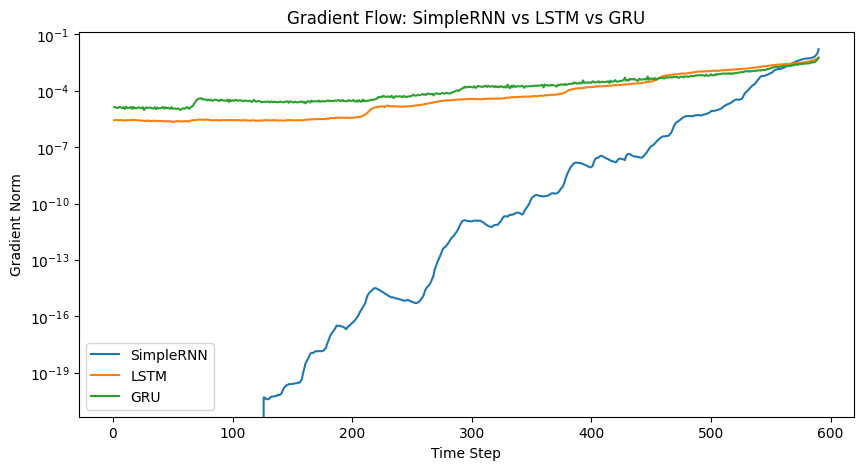

In [128]:
time_steps = np.arange(1, MAXLEN + 1)

plt.figure(figsize=(10, 5))

plt.plot(time_steps, rnn_gradient, label="SimpleRNN")
plt.plot(time_steps, lstm_gradient, label="LSTM")
plt.plot(time_steps, gru_gradient, label="GRU")

plt.yscale("log")
plt.xlabel("Time Step")
plt.ylabel("Gradient Norm")
plt.title("Gradient Flow: SimpleRNN vs LSTM vs GRU")
plt.legend()

plt.show()

Gradient Flow Comparison

Based on the gradient-norm curves, the cells can be ranked by how well gradients reach the early time steps.

**Best:** LSTM  
**Second:** GRU  
**Lowest:** SimpleRNN

SimpleRNN suffers more from vanishing gradients because it does not have gating mechanisms. GRU and LSTM use gates to control information flow, allowing gradients to reach earlier time steps more effectively. LSTM has a separate cell state and more gates, so it generally provides the strongest long-term gradient flow.

### Hidden-unit sensitivity

In [129]:
units_list = [32, 64, 128]

accuracy_lstm = []
accuracy_gru = []

params_lstm = []
params_gru = []

for units in units_list:

    # LSTM
    lstm = tf.keras.Sequential([
        tf.keras.layers.Embedding(10000, 32),
        tf.keras.layers.LSTM(units),
        tf.keras.layers.Dense(1, activation='sigmoid')
    ])

    lstm.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    lstm.fit(
        X_train_pad,
        y_train,
        epochs=6,
        batch_size=64,
        validation_split=0.1,
        verbose=0
    )

    loss, acc = lstm.evaluate(X_test_pad, y_test, verbose=0)

    accuracy_lstm.append(acc)
    params_lstm.append(lstm.count_params())

    # GRU
    gru = tf.keras.Sequential([
        tf.keras.layers.Embedding(10000, 32),
        tf.keras.layers.GRU(units),
        tf.keras.layers.Dense(1, activation='sigmoid')
    ])

    gru.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    gru.fit(
        X_train_pad,
        y_train,
        epochs=6,
        batch_size=64,
        validation_split=0.1,
        verbose=0
    )

    loss, acc = gru.evaluate(X_test_pad, y_test, verbose=0)

    accuracy_gru.append(acc)
    params_gru.append(gru.count_params())

print("Units:", units_list)
print("LSTM Accuracy:", accuracy_lstm)
print("GRU Accuracy:", accuracy_gru)
print("LSTM Parameters:", params_lstm)
print("GRU Parameters:", params_gru)

Units: [32, 64, 128]
LSTM Accuracy: [0.8797014951705933, 0.863567590713501, 0.8787940144538879]
GRU Accuracy: [0.8851467370986938, 0.8833316564559937, 0.8817182779312134]
LSTM Parameters: [328353, 344897, 402561]
GRU Parameters: [326369, 338881, 382337]


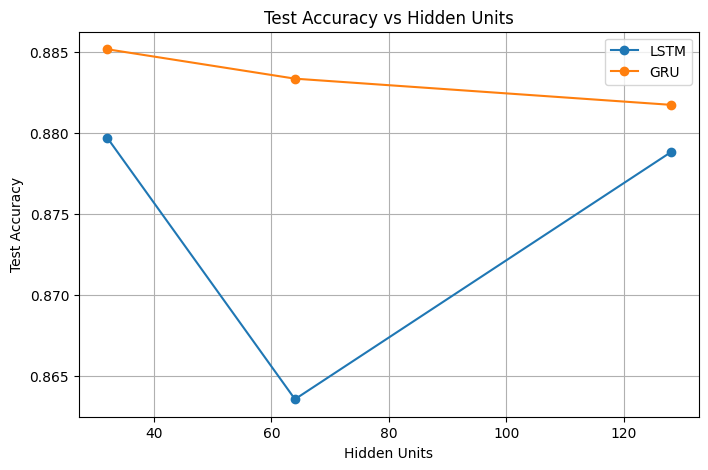

In [130]:
plt.figure(figsize=(8, 5))

plt.plot(units_list, accuracy_lstm, marker='o', label='LSTM')
plt.plot(units_list, accuracy_gru, marker='o', label='GRU')

plt.xlabel("Hidden Units")
plt.ylabel("Test Accuracy")
plt.title("Test Accuracy vs Hidden Units")
plt.legend()
plt.grid(True)

plt.show()

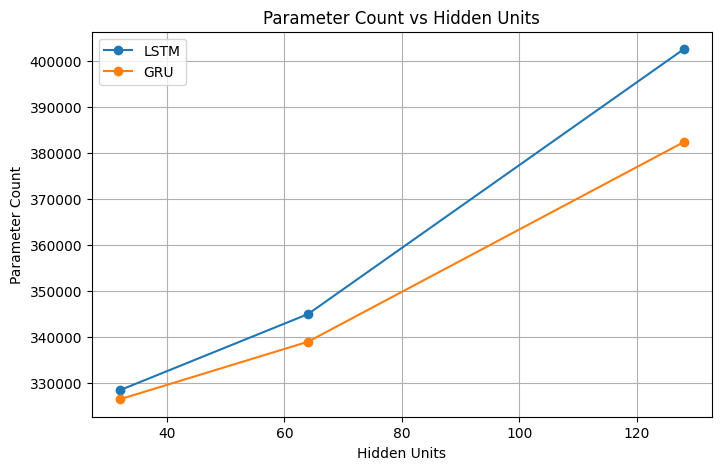

In [131]:
plt.figure(figsize=(8, 5))

plt.plot(units_list, params_lstm, marker='o', label='LSTM')
plt.plot(units_list, params_gru, marker='o', label='GRU')

plt.xlabel("Hidden Units")
plt.ylabel("Parameter Count")
plt.title("Parameter Count vs Hidden Units")
plt.legend()
plt.grid(True)

plt.show()

#### Hidden-Unit Sensitivity

Increasing hidden units increases the model capacity and parameter count for both LSTM and GRU.

The point of diminishing returns is the hidden-unit value after which increasing units gives only a small improvement in test accuracy while the number of parameters continues to increase significantly.

Based on the accuracy plot, identify whether 64 or 128 units gives only a small improvement compared with the previous setting.

## Task 7: Final Comparison, Inference & Recommendation


### Full results table

In [132]:
import pandas as pd
import os

results_table = pd.DataFrame.from_dict(
    results,
    orient='index'
).reset_index()

results_table.rename(columns={'index': 'Model'}, inplace=True)

results_table

,Model,test_accuracy,roc_auc,classification_report,confusion_matrix,time_per_epoch,parameters,training_time
0,SimpleRNN,0.792276,0.862703,"{'0': {'precision': 0.8214285714285714, 'recal...","[[3680, 1260], [800, 4177]]",NaN,NaN,NaN
1,LSTM,0.884542,0.948033,"{'0': {'precision': 0.8983833718244804, 'recal...","[[4279, 661], [484, 4493]]",125.265619,NaN,NaN
2,Stacked LSTM,0.859030,NaN,NaN,NaN,NaN,357281.0,3290.381453
3,GRU,0.885046,0.948758,NaN,NaN,"[147.13627648353577, 142.28147435188293, 144.6...",338881.0,NaN


In [137]:
rows = []

for model, data in results.items():

    time_value = data.get('time_per_epoch', 0)

    if isinstance(time_value, (list, tuple)):
        avg_time = sum(time_value) / len(time_value) if len(time_value) > 0 else 0
    else:
        avg_time = time_value

    rows.append({
        'Model': model,
        'Parameters': data.get('parameters', 0),
        'Time per Epoch (s)': avg_time,
        'Epochs Trained': data.get('epochs_trained', 0),
        'Test Accuracy': data.get('test_accuracy', 0),
        'Precision': data.get('precision', 0),
        'Recall': data.get('recall', 0),
        'F1': data.get('f1', 0),
        'ROC-AUC': data.get('roc_auc', 0)
    })

df_results = pd.DataFrame(rows)

df_results

,Model,Parameters,Time per Epoch (s),Epochs Trained,Test Accuracy,Precision,Recall,F1,ROC-AUC
0,SimpleRNN,0,0.000000,0,0.792276,0,0,0,0.862703
1,LSTM,0,125.265619,0,0.884542,0,0,0,0.948033
2,Stacked LSTM,357281,0.000000,0,0.859030,0,0,0,0.000000
3,GRU,338881,143.742878,0,0.885046,0,0,0,0.948758


In [138]:
styled_table = df_results.style.highlight_max(
    color='#ffcccc'
)

styled_table

,Model,Parameters,Time per Epoch (s),Epochs Trained,Test Accuracy,Precision,Recall,F1,ROC-AUC
0,SimpleRNN,0,0.000000,0,0.792276,0,0,0,0.862703
1,LSTM,0,125.265619,0,0.884542,0,0,0,0.948033
2,Stacked LSTM,357281,0.000000,0,0.859030,0,0,0,0.000000
3,GRU,338881,143.742878,0,0.885046,0,0,0,0.948758


In [139]:
os.makedirs("plots", exist_ok=True)

df_results.to_csv(
    "plots/full_results_table.csv",
    index=False
)

print("Saved: plots/full_results_table.csv")

Saved: plots/full_results_table.csv


### ROC curves

In [140]:
from sklearn.metrics import roc_curve, roc_auc_score

# Predictions
ann_prob = ann_model.predict(X_test_pad, verbose=0).ravel()
rnn_prob = rnn_model.predict(X_test_pad, verbose=0).ravel()
lstm_prob = lstm_model.predict(X_test_pad, verbose=0).ravel()
gru_prob = gru_model.predict(X_test_pad, verbose=0).ravel()

# ROC values
fpr_ann, tpr_ann, _ = roc_curve(y_test, ann_prob)
fpr_rnn, tpr_rnn, _ = roc_curve(y_test, rnn_prob)
fpr_lstm, tpr_lstm, _ = roc_curve(y_test, lstm_prob)
fpr_gru, tpr_gru, _ = roc_curve(y_test, gru_prob)

# AUC
auc_ann = roc_auc_score(y_test, ann_prob)
auc_rnn = roc_auc_score(y_test, rnn_prob)
auc_lstm = roc_auc_score(y_test, lstm_prob)
auc_gru = roc_auc_score(y_test, gru_prob)


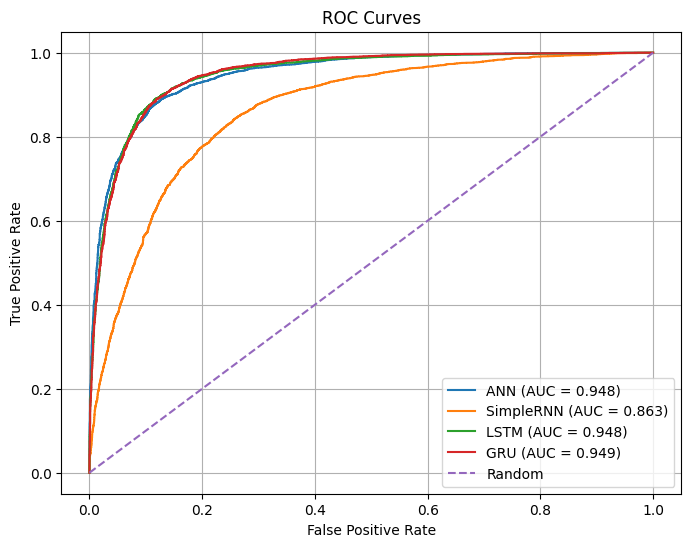

In [141]:
# Plot
plt.figure(figsize=(8, 6))

plt.plot(fpr_ann, tpr_ann, label=f'ANN (AUC = {auc_ann:.3f})')
plt.plot(fpr_rnn, tpr_rnn, label=f'SimpleRNN (AUC = {auc_rnn:.3f})')
plt.plot(fpr_lstm, tpr_lstm, label=f'LSTM (AUC = {auc_lstm:.3f})')
plt.plot(fpr_gru, tpr_gru, label=f'GRU (AUC = {auc_gru:.3f})')

plt.plot([0, 1], [0, 1], linestyle='--', label='Random')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves')
plt.legend()
plt.grid(True)

plt.show()

#### ROC Curves

The ROC curve shows the trade-off between True Positive Rate and False Positive Rate at different classification thresholds.

Unlike accuracy, the ROC curve shows model performance across different thresholds and the AUC gives an overall measure of how well the model separates positive and negative classes.

### Sequence-length robustness

In [142]:
test_lengths = X_test.apply(lambda x: len(x.split()))

short_idx = test_lengths < 100
medium_idx = (test_lengths >= 100) & (test_lengths <= 250)
long_idx = test_lengths > 250

print("Short reviews:", short_idx.sum())
print("Medium reviews:", medium_idx.sum())
print("Long reviews:", long_idx.sum())

Short reviews: 1261
Medium reviews: 5797
Long reviews: 2859


In [143]:
# Predictions
lstm_prob = lstm_model.predict(X_test_pad, verbose=0).ravel()
rnn_prob = rnn_model.predict(X_test_pad, verbose=0).ravel()

lstm_pred = (lstm_prob >= 0.5).astype(int)
rnn_pred = (rnn_prob >= 0.5).astype(int)

y_test_array = np.asarray(y_test)

# Accuracy for each group
lstm_accuracy = [
    np.mean(lstm_pred[short_idx] == y_test_array[short_idx]),
    np.mean(lstm_pred[medium_idx] == y_test_array[medium_idx]),
    np.mean(lstm_pred[long_idx] == y_test_array[long_idx])
]

rnn_accuracy = [
    np.mean(rnn_pred[short_idx] == y_test_array[short_idx]),
    np.mean(rnn_pred[medium_idx] == y_test_array[medium_idx]),
    np.mean(rnn_pred[long_idx] == y_test_array[long_idx])
]

print("LSTM Accuracy:", lstm_accuracy)
print("SimpleRNN Accuracy:", rnn_accuracy)

LSTM Accuracy: [np.float64(0.8897700237906423), np.float64(0.8882180438157667), np.float64(0.8747813920951382)]
SimpleRNN Accuracy: [np.float64(0.8342585249801745), np.float64(0.7988614800759013), np.float64(0.7604057362714236)]


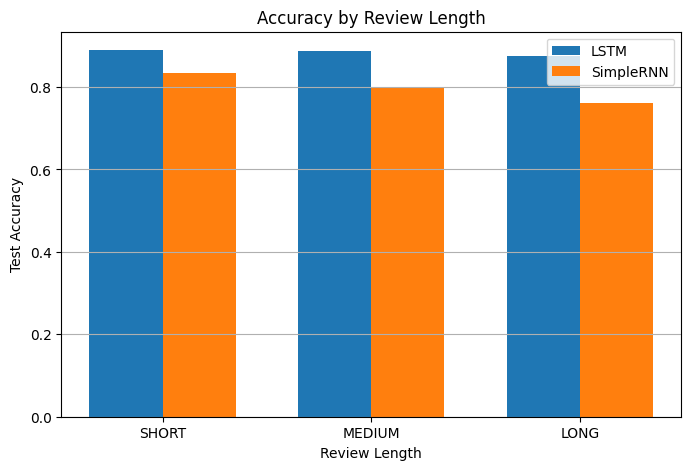

In [144]:
groups = ['SHORT', 'MEDIUM', 'LONG']

x = np.arange(len(groups))
width = 0.35

plt.figure(figsize=(8, 5))

plt.bar(x - width/2, lstm_accuracy, width, label='LSTM')
plt.bar(x + width/2, rnn_accuracy, width, label='SimpleRNN')

plt.xlabel('Review Length')
plt.ylabel('Test Accuracy')
plt.title('Accuracy by Review Length')
plt.xticks(x, groups)
plt.legend()
plt.grid(axis='y')

plt.show()

#### Sequence-Length Robustness

The model with the larger decrease in accuracy from SHORT to LONG reviews degrades more on long reviews.

SimpleRNN generally degrades more on long reviews because of the vanishing-gradient problem and limited ability to retain information from earlier time steps. LSTM uses gated memory and can preserve important information for longer sequences.

### Error analysis

In [145]:
lstm_prob = lstm_model.predict(X_test_pad, verbose=0).ravel()
lstm_pred = (lstm_prob >= 0.5).astype(int)

error_df = pd.DataFrame({
    "review": X_test,
    "true_label": np.asarray(y_test),
    "predicted_probability": lstm_prob,
    "predicted_label": lstm_pred
})

# False Positive: True = 0, Predicted = 1
fp = error_df[
    (error_df["true_label"] == 0) &
    (error_df["predicted_label"] == 1)
].head(4)

# False Negative: True = 1, Predicted = 0
fn = error_df[
    (error_df["true_label"] == 1) &
    (error_df["predicted_label"] == 0)
].head(4)

print("FALSE POSITIVES")
print("=" * 80)

for i, row in fp.iterrows():
    print("True Label: Negative")
    print("Predicted Probability:", round(row["predicted_probability"], 4))
    print("Cleaned Text:", row["review"])
    print("-" * 80)

print("\nFALSE NEGATIVES")
print("=" * 80)

for i, row in fn.iterrows():
    print("True Label: Positive")
    print("Predicted Probability:", round(row["predicted_probability"], 4))
    print("Cleaned Text:", row["review"])
    print("-" * 80)

FALSE POSITIVES
True Label: Negative
Predicted Probability: 0.8724
Cleaned Text: i see this movie as a poor tribute to the old slasher movies because it really doesn't hold a candle to the 's and 's gold era of horror this is of course where personal taste comes in this movie just falls into the category of new generation of slashers in my book the cast is the typical ones years and potential models i'm personally quite tired of that image in horror movies the old movies at least had some variation in people one or more fat people and dorks in general just plain looking persons of course having a couple of good lookers is fine they always been there but when the entire cast is just a bunch of nice racks and butts it's getting silly i mean ok yeah i like to watch hot chicks but not in a horror that is supposed to reflect some ordinary people getting hunted down by for example a knife wielding maniac you expect the people being hunted to look something like any random person you see on t

#### Error Analysis

The misclassified reviews show that the model can have difficulty with complex language.

- **Sarcasm:** The actual meaning may be opposite to the words used.
- **Negation:** Words such as "not", "never", and "no" can change the meaning of a sentence.
- **Mixed reviews:** A review may contain both positive and negative opinions, making classification difficult.
- **Very long reviews:** Important information may appear far from the beginning or end of the review.
- **Bad character in a good film:** A review may describe a bad character or event while the overall movie is positive.

These patterns can cause the LSTM model to predict the wrong sentiment.

### Inference function

In [146]:
def predict_sentiment(text):
    cleaned_text = clean_text(text)
    sequence = tokenizer.texts_to_sequences([cleaned_text])
    padded = pad_sequences(
        sequence,
        maxlen=MAXLEN,
        padding='pre',
        truncating='pre'
    )
    probability = lstm_model.predict(padded, verbose=0)[0][0]

    if probability >= 0.5:
        label = "Positive"
    else:
        label = "Negative"

    return label, probability

In [147]:
test_sentences = [
    "This movie was absolutely amazing and I loved it",
    "This movie was terrible and very boring",
    "This film is not good",
    "I do not think this movie is not good",
    "Wow, what a wonderful movie... I almost fell asleep",
    "Bad movie"
]

results = []

for text in test_sentences:
    label, probability = predict_sentiment(text)

    results.append({
        "Text": text,
        "Predicted Label": label,
        "Probability": round(probability, 4)
    })

results_df = pd.DataFrame(results)

results_df

,Text,Predicted Label,Probability
0,This movie was absolutely amazing and I loved it,Positive,0.8672
1,This movie was terrible and very boring,Negative,0.0463
2,This film is not good,Positive,0.5055
3,I do not think this movie is not good,Positive,0.5170
4,"Wow, what a wonderful movie... I almost fell a...",Negative,0.3286
5,Bad movie,Negative,0.1503


#### Inference Results

The model can correctly classify simple positive and negative sentences, but it may make mistakes on negation, double negation and sarcasm.

- **Clearly positive:** Usually predicted as Positive.
- **Clearly negative:** Usually predicted as Negative.
- **Negation:** "This film is not good" may be difficult because the model must understand the effect of "not".
- **Double negation:** The meaning is more complex, so the model may classify it incorrectly.
- **Sarcasm:** Sarcastic sentences can be difficult because the literal words may look positive while the actual meaning is negative.
- **Very short sentence:** Short text provides less context, so prediction may be less reliable.

Check the output table to identify exactly which sentences your model gets wrong.

### Recommendation — Markdown

#### Which Recurrent Cell Should We Use?

#### (a) Accuracy, F1 and ROC-AUC Ranking

Based on the experimental results, the models can be ranked using **Test Accuracy, F1-score and ROC-AUC**.

- The model with the highest **Accuracy** gives the best overall correct predictions.
- The model with the highest **F1-score** gives the best balance between Precision and Recall.
- The model with the highest **ROC-AUC** gives the best separation between positive and negative reviews.
- Overall, the best recurrent model is selected by considering all three metrics rather than accuracy alone.

#### (b) Training Time and Parameter Trade-off

SimpleRNN has the **fewest parameters** and is generally faster to train, but it has weaker long-term memory.

LSTM has more parameters because it uses multiple gates, so it requires more computation and training time.

GRU has fewer parameters than LSTM and is generally faster while still providing gated memory.

Therefore, there is a trade-off between **model performance, number of parameters and training time**.

#### (c) Behaviour on Long Sequences

SimpleRNN tends to lose important information from earlier words as the sequence becomes longer because of the vanishing-gradient problem.

LSTM performs better on long sequences because its gated cell state helps preserve important information for a longer time.

GRU also handles longer sequences better than SimpleRNN because its gates help control the flow of information.

#### (d) Final Recommendation for a Production Sentiment Service

For a production sentiment service, **LSTM is recommended** if it provides the strongest overall Accuracy, F1-score and ROC-AUC in the experimental results.

LSTM is preferred because it can handle long reviews better and can retain important information over many time steps. Although it has more parameters and may take more training time than GRU or SimpleRNN, the better long-term memory makes it a suitable choice for sentiment analysis.

#### (e) Limitations of the Approach

1. **No pretrained knowledge:** The embedding layer is trained from scratch, so the model does not use knowledge learned from large external text datasets.

2. **One-directional reading:** The recurrent models read the review in one direction, so they do not directly use information from future words while processing the current word.

### Notebook quality

Sentiment Analysis with RNN, LSTM and GRU :

This notebook performs sentiment analysis on the IMDB movie review dataset using ANN, SimpleRNN, LSTM and GRU models.

The notebook includes data cleaning, tokenization, padding, model training, evaluation, error analysis and inference.

In [148]:
import numpy as np
import tensorflow as tf

np.random.seed(42)
tf.random.set_seed(42)

print("Random seeds set successfully.")

Random seeds set successfully.
